# 🧬 Bacterial Cell Lineage Tracker (TrackMate → Statistics)

**Pipeline Step 1:** Convert TrackMate tracking data into cell-by-cell statistics with lineage information

---

## 📋 What This Notebook Does

This pipeline analyzes bacterial cell division from **TrackMate** (Fiji/ImageJ) tracking exports:

1. **Loads** TrackMate `spots.csv` and `edges.csv` files  
2. **Reconstructs** mother-daughter lineage trees using graph theory  
3. **Calculates** growth rates, division timing, and morphology metrics (length, width, area, etc.)  
4. **Validates** division events using physics-based quality filters  
5. **Exports** clean statistics ready for population-level comparison  

You can run this notebook in **Jupyter** or **Google Colab**. In Colab, you will select your data folder using a simple number-based menu (no path editing required).

---

## 📥 Required Input Files

From TrackMate (File → Export → Export to CSV):

- `*_spots.csv` – Cell positions, sizes, and shape metrics over time  
- `*_edges.csv` – Parent-child linkages between timepoints  

**Important:** Files must be paired (same prefix). Example:  
`20260101_L206K_mreB_s1_spots.csv` / `20260101_L206K_mreB_s1_edges.csv`

---

## 📤 Output Files

After processing, all results are written into a `Results/` folder inside your input folder:

- `Results/AllBranchesStats.csv` – Cell-by-cell statistics (⭐ main output)  
- `Results/AllLineagePaths.csv` – Complete lineage paths (t1→t2→t3→…)  
- `Results/CombinedCVReport.txt` – Coefficient of variation diagnostics  
- `Results/GrowthModelProof.txt` – Adder/Sizer/Timer classification per file  
- `Results/LineagePathDetails/Plots_by_Generation/...` – Plots grouped by what they show  
- `Results/LineagePathDetails/Other_QC/...` – Dashboards, tree galleries, networks  

---

## 🚀 Quick Start

1. **Run Section 2** (Environment & imports)  
2. **Edit Section 3** (Analysis parameters) to match your experiment  
3. **Run Section 4** to select your input folder and configure outputs  
4. **Run all remaining sections** to process data and generate plots  

**Estimated runtime:** ~30 seconds per input file pair (depending on dataset size)

---

## 💡 Need Help?

- **TrackMate export not working?** See `docs/trackmate_export_guide.md`  
- **Getting validation errors?** Adjust quality thresholds in Section 3  
- **Want to understand the statistics?** See `docs/output_column_guide.md`  

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JoeVPhD/TrackMate_CellPose_Bacterial_Generation_Determination/blob/main/TrackMate_CellPose_Bacterial_Generation_Determination.ipynb)


## 2. 🔧 Environment & Imports

This section:

- Detects whether you are running in **Google Colab** or a local **Jupyter Notebook**.  
- Installs required Python packages automatically in Colab.  
- Imports all libraries needed for the analysis.  
- Configures plotting for notebooks.  
- Prints versions of key libraries for reproducibility.


In [4]:
# ═══════════════════════════════════════════════════════════════
# 🔧 INSTALLATION & IMPORTS
# ═══════════════════════════════════════════════════════════════

import sys
import os

# Detect environment
IN_COLAB = 'google.colab' in sys.modules
IN_JUPYTER = 'ipykernel' in sys.modules

print(f"🖥️ Environment: {'Google Colab' if IN_COLAB else 'Jupyter Notebook' if IN_JUPYTER else 'Python Script'}")

# Install dependencies (Colab only)
if IN_COLAB:
    print("📦 Installing required packages...")
    !pip install -q pandas numpy matplotlib seaborn scipy networkx
    from google.colab import drive  # Import drive here to be ready
    print("✅ Installation complete!")

# Core imports
from pathlib import Path
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from scipy.stats import linregress, skew, kurtosis

# Configure matplotlib for notebook display
if IN_COLAB or IN_JUPYTER:
    %matplotlib inline
else:
    matplotlib.use('Agg')  # File output only

warnings.filterwarnings('ignore')

print("✅ All imports successful!")
print(f"📊 Pandas: {pd.__version__} | NumPy: {np.__version__} | NetworkX: {nx.__version__}")


🖥️ Environment: Google Colab
📦 Installing required packages...
✅ Installation complete!
✅ All imports successful!
📊 Pandas: 2.2.2 | NumPy: 2.0.2 | NetworkX: 3.6.1



---

## 📤 Output Files (Per Input Pair)

- `*_AllBranchesStats.csv` - Cell-by-cell statistics (main output)
- `*_LineagePaths.csv` - Complete lineage paths (t1→t2→t3→...)
- `*_CVReport.txt` - Coefficient of variation diagnostics
- `*_LineageTrees.png` - Visual gallery of example lineage trees
- `*_Network_*.png` - Graph diagram of branching structure
- `LineagePathDetails/*.png` - Individual high-quality lineage traces

**Plus combined outputs:**
- `AllBranchesStats.csv` - All experiments merged
- `AllLineagePaths.csv` - All lineages merged
- `CombinedCVReport.txt` - Population-level variance report
- `GrowthModelProof.txt` - Adder/Sizer/Timer classification per file

---

## 🚀 Quick Start

1. **Run Cell 2** to install dependencies
2. **Edit Cell 3** to set your imaging parameters (frame interval, thresholds)
3. **Run Cell 4** to select your input folder
4. **Run All** remaining cells

**Estimated runtime:** ~30 seconds per input file pair

---

## 💡 Need Help?

- **TrackMate export not working?** See [docs/trackmate_export_guide.md](../docs/trackmate_export_guide.md)
- **Getting validation errors?** Adjust quality thresholds in Cell 3
- **Want to understand the statistics?** See [docs/output_column_guide.md](../docs/output_column_guide.md)

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JoeVPhD/TrackMate_CellPose_Bacterial_Generation_Determination/blob/main/TrackMate_CellPose_Bacterial_Generation_Determination.ipynb)

In [5]:
# ═══════════════════════════════════════════════════════════════
# 🔧 INSTALLATION & IMPORTS
# ═══════════════════════════════════════════════════════════════

import sys
import os

# Detect environment
IN_COLAB = 'google.colab' in sys.modules
IN_JUPYTER = 'ipykernel' in sys.modules

print(f"🖥️  Environment: {'Google Colab' if IN_COLAB else 'Jupyter Notebook' if IN_JUPYTER else 'Python Script'}")

# Install dependencies (Colab only)
if IN_COLAB:
    print("📦 Installing required packages...")
    !pip install -q pandas numpy matplotlib seaborn scipy networkx
    from google.colab import drive # Import drive here to be ready
    print("✅ Installation complete!")

# Core imports
from pathlib import Path
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from scipy.stats import linregress, skew, kurtosis

# Configure matplotlib for notebook display
if IN_COLAB or IN_JUPYTER:
    %matplotlib inline
else:
    matplotlib.use('Agg')  # File output only

warnings.filterwarnings('ignore')

print("✅ All imports successful!")
print(f"📊 Pandas: {pd.__version__} | NumPy: {np.__version__} | NetworkX: {nx.__version__}")


🖥️  Environment: Google Colab
📦 Installing required packages...
✅ Installation complete!
✅ All imports successful!
📊 Pandas: 2.2.2 | NumPy: 2.0.2 | NetworkX: 3.6.1


### 2.1 Google Drive (Colab only)

If you are running in **Google Colab**, this cell will mount your Google Drive so you can browse to your data folder using a simple menu. In local Jupyter, this does nothing.


In [6]:
if IN_COLAB:
    # Drive may already be imported above; this is safe either way.
    from google.colab import drive
    if not Path("/content/drive").exists():
        print("📌 Mounting Google Drive...")
        drive.mount('/content/drive')
    else:
        print("📁 Google Drive already mounted.")
else:
    print("Not in Colab: skipping Google Drive mount.")


📌 Mounting Google Drive...
Mounted at /content/drive


## 3. ⚙️ Analysis Parameters (Edit These!)

This is the main configuration cell for your experiment. You should:

- Set the **frame interval** to match your microscope.  
- Adjust **quality filters** (division symmetry, mass conservation, jump limit, growth rate, R²).  
- Set **minimum track lengths** for mothers and daughters.  
- Optionally change **visualization limits** (how many example trees and detailed plots).  

Most users will only need to edit values in this cell.


In [7]:
# ═══════════════════════════════════════════════════════════════
# ⚙️ ANALYSIS PARAMETERS (EDIT THESE!)
# ═══════════════════════════════════════════════════════════════

# ────────────────────────────────────────────────────────────────
# 📸 IMAGING PARAMETERS
# ────────────────────────────────────────────────────────────────
FRAME_INTERVAL = 2.0  # Minutes per frame (CRITICAL: match your microscope settings!)

# ────────────────────────────────────────────────────────────────
# 🧪 QUALITY FILTERS (Relaxed = More Data, Strict = Cleaner Data)
# ────────────────────────────────────────────────────────────────

# Division Symmetry
THRESH_BALANCE = 0.75       # Sister size ratio (0.75 = 25% asymmetry allowed)
                            # Smaller daughter / Larger daughter must be ≥ this

# Mass Conservation
THRESH_CONS_MIN = 0.85      # Min mass conservation (daughters vs mother area)
THRESH_CONS_MAX = 1.15      # Max mass conservation

# Spatial Jumps
THRESH_JUMP_MULT = 1.5      # Max jump = cell_length × this multiplier
                            # Prevents tracking errors (teleporting cells)

# Growth Rate
THRESH_GROWTH = 0.5         # Max instantaneous growth rate (50% per frame)
                            # Flags measurement artifacts

# Exponential Fit Quality
THRESH_R2 = 0.90            # Minimum R² for growth curve (0.90 = 90% fit)
                            # Only accept clean exponential growth

# ────────────────────────────────────────────────────────────────
# 📏 MINIMUM TRACK LENGTHS (Frames)
# ────────────────────────────────────────────────────────────────
MIN_DURATION_MOTHER = 5     # Gen 1 must last ≥5 frames (~10 min @ 2min/frame)
MIN_DURATION_DAUGHTER = 3   # Gen 2+ can be shorter (allow faster dividers)

# ────────────────────────────────────────────────────────────────
# 📊 VISUALIZATION
# ────────────────────────────────────────────────────────────────
MAX_LINEAGE_EXAMPLES = 6    # Number of example trees to plot
MAX_DETAIL_PLOTS = 20       # Number of individual lineage traces

print("✅ Configuration loaded!")
print(f"⏱️  Frame interval: {FRAME_INTERVAL} minutes")
print(f"🎯 Quality mode: {'Strict' if THRESH_R2 >= 0.95 else 'Standard' if THRESH_R2 >= 0.85 else 'Relaxed'}")


✅ Configuration loaded!
⏱️  Frame interval: 2.0 minutes
🎯 Quality mode: Standard


## 4. 📂 Input & Output Setup

In this section you will:

1. **Select** the folder containing your TrackMate CSV files using a simple number-based menu.  
2. **Verify** that Spot (`*_spots.csv`) and Edge (`*_edges.csv`) files are present.  
3. **Define** a standard `Results/` folder structure where all outputs will be saved.

This works both in **Colab** and in **local Jupyter**.

In [8]:
# ═══════════════════════════════════════════════════════════════
# 📂 INPUT FOLDER SELECTION
# ═══════════════════════════════════════════════════════════════

def _browse_dirs_cli(start_dir: Path) -> Path:
    """Simple interactive directory browser (works in Colab)."""
    cur = start_dir

    while True:
        if not cur.exists():
            print(f"❌ Folder not found: {cur}")
            cur = start_dir
            continue

        # Get subdirectories only
        try:
            subdirs = sorted([p for p in cur.iterdir() if p.is_dir()],
                             key=lambda p: p.name.lower())
        except PermissionError:
            print("🚫 Permission denied. Going up...")
            cur = cur.parent
            continue

        print("\n" + "─" * 70)
        print(f"📁 Current folder: {cur}")
        print("Type:")
        print("  0  = ✅ SELECT THIS FOLDER")
        print("  .. = ⬆️ Go up one level")
        print("\nSubfolders:")
        for i, d in enumerate(subdirs, start=1):
            print(f"  {i:>2}. {d.name}/")

        choice = input("\n👇 Select number (or '0' to finish): ").strip()

        if choice == "0":
            return cur

        if choice == "..":
            cur = cur.parent
            continue

        if choice.isdigit():
            idx = int(choice)
            if 1 <= idx <= len(subdirs):
                cur = subdirs[idx - 1]
                continue

        # Handle manual path pasting or errors
        p = Path(choice)
        if p.is_absolute() and p.exists() and p.is_dir():
            cur = p
        else:
            print("❌ Invalid selection. Enter a number, '..', '0', or a valid absolute path.")

def select_input_folder():
    """Platform-aware folder picker."""
    if IN_COLAB:
        print("🔗 Google Colab detected!")

        # 1. Mount Drive if missing
        if not Path("/content/drive").exists():
            print("📌 Mounting Google Drive...")
            from google.colab import drive
            drive.mount('/content/drive')

        # 2. Start browser at MyDrive
        print("\n🚀 Launching Folder Browser...")
        return _browse_dirs_cli(Path("/content/drive/MyDrive"))

    else:
        # Local Jupyter: use system dialog
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)

        print("Please check your taskbar for the folder selection window...")
        folder = filedialog.askdirectory(title="Select folder containing TrackMate CSVs")
        root.destroy()

        return Path(folder) if folder else None

# --- EXECUTE ---
INPUT_FOLDER = select_input_folder()

if INPUT_FOLDER:
    print(f"\n✅ Selected: {INPUT_FOLDER}")
    # Verify contents
    spots = list(INPUT_FOLDER.glob("*spots.csv"))
    print(f"Found {len(spots)} spot files.")
else:
    print("\n❌ No folder selected.")


🔗 Google Colab detected!

🚀 Launching Folder Browser...

──────────────────────────────────────────────────────────────────────
📁 Current folder: /content/drive/MyDrive
Type:
  0  = ✅ SELECT THIS FOLDER
  .. = ⬆️ Go up one level

Subfolders:
   1. 100MSDCF/
   2. Camera/
   3. Canvas photos/
   4. CEA Notebook/
   5. Cell Shape (Joe)/
   6. CoinbaseWalletBackups/
   7. Colab Notebooks/
   8. Colab_Notebooks/
   9. Desktop Documents/
  10. Electrode Project/
  11. Final Budget Proposals/
  12. Food/
  13. Joe's Marie Currie/
  14. Journal/
  15. Lab Material/
  16. Light Business-Joe/
  17. MCDB Core 2017/
  18. My Brain 20240815/
  19. Old Meeting Notes/
  20. Paris/
  21. Paris Docs/
  22. PDRD 2023/
  23. Random Personal/
  24. Screen Team/
  25. SMART/
  26. SMART 2021/
  27. STEM Routes/
  28. STEM Routes Budget Proposal Drafts/
  29. Uploads from Computer/

👇 Select number (or '0' to finish): 8

──────────────────────────────────────────────────────────────────────
📁 Current folde

In [9]:
# ═══════════════════════════════════════════════════════════════
# 📤 OUTPUT CONFIGURATION
# ═══════════════════════════════════════════════════════════════

if INPUT_FOLDER:
    OUTPUT_FOLDER = INPUT_FOLDER / "Results"
    OUTPUT_FOLDER.mkdir(exist_ok=True)

    # Main combined outputs
    ALL_BRANCHES_FILE = OUTPUT_FOLDER / "AllBranchesStats.csv"
    ALL_LINEAGES_FILE = OUTPUT_FOLDER / "AllLineagePaths.csv"
    COMBINED_CV_FILE = OUTPUT_FOLDER / "CombinedCVReport.txt"
    GROWTH_MODEL_FILE = OUTPUT_FOLDER / "GrowthModelProof.txt"

    # Plot root directory
    LINEAGE_DETAIL_ROOT = OUTPUT_FOLDER / "LineagePathDetails"
    LINEAGE_DETAIL_ROOT.mkdir(exist_ok=True)

    print("✅ Results will be saved to:")
    print(f" 📁 {OUTPUT_FOLDER}\n")

    print("📊 Output structure:")
    print(" Results/")
    print(" ├── AllBranchesStats.csv      (⭐ Main output)")
    print(" ├── AllLineagePaths.csv")
    print(" ├── CombinedCVReport.txt")
    print(" ├── GrowthModelProof.txt")
    print(" └── LineagePathDetails/       (Plots grouped by what they show)")
else:
    print("⚠️ Skipped: No input folder selected yet.")


✅ Results will be saved to:
 📁 /content/drive/MyDrive/Colab_Notebooks/TrackerFiles/Results

📊 Output structure:
 Results/
 ├── AllBranchesStats.csv      (⭐ Main output)
 ├── AllLineagePaths.csv
 ├── CombinedCVReport.txt
 ├── GrowthModelProof.txt
 └── LineagePathDetails/       (Plots grouped by what they show)


## 5. 🧾 TrackMate Loader & Metadata

These functions:

- Load raw TrackMate `*_spots.csv` and `*_edges.csv` files.  
- Normalize column names (IDs, positions, geometry).  
- Extract simple metadata (date, gene, condition) from the filename stem.


In [10]:
# ═══════════════════════════════════════════════════════════════
# 1️⃣ TRACKMATE DATA LOADER
# ═══════════════════════════════════════════════════════════════

def load_trackmate_data(spots_path, edges_path):
    """
    Load and normalize TrackMate spot/edge CSV exports.

    Handles:
    - TrackMate's 4-line header format
    - Column name variations (POSITION_T vs FRAME)
    - Geometric measurements (major/minor axis, circularity, etc.)

    Returns:
        spots (DataFrame): Cell measurements per timepoint
        edges (DataFrame): Parent-child linkages
    """

    # Read headers from line 1 (TrackMate format)
    with open(spots_path, 'r', encoding='utf-8') as f:
        h_spots = f.readline().strip().split(',')
    with open(edges_path, 'r', encoding='utf-8') as f:
        h_edges = f.readline().strip().split(',')

    # Load data (skip 4-line header)
    spots = pd.read_csv(spots_path, names=h_spots, skiprows=4, encoding='utf-8', low_memory=False)
    edges = pd.read_csv(edges_path, names=h_edges, skiprows=4, encoding='utf-8', low_memory=False)

    # Clean column names
    spots.columns = spots.columns.str.strip()
    edges.columns = edges.columns.str.strip()

    # Standardize column names (TrackMate variations)
    column_map = {
        'ID': 'ID',
        'TRACK_ID': 'TRACK_ID',
        'AREA': 'AREA',
        'POSITION_X': 'POSITION_X',
        'POSITION_Y': 'POSITION_Y',
        'ELLIPSE_MAJOR': 'MAJOR',
        'ELLIPSE_MINOR': 'MINOR',
        'POSITION_T': 'FRAME',
        'PERIMETER': 'PERIMETER',
        'CIRCULARITY': 'CIRCULARITY',
        'SOLIDITY': 'SOLIDITY',
        'SHAPE_INDEX': 'SHAPE_INDEX',
        'ELLIPSE_THETA': 'ANGLE'
    }

    # Handle FRAME vs POSITION_T
    if 'FRAME' in spots.columns:
        column_map.pop('POSITION_T', None)

    edge_map = {
        'SPOT_SOURCE_ID': 'SOURCE',
        'SPOT_TARGET_ID': 'TARGET'
    }

    # Rename
    spots = spots.rename(columns={c: column_map[c] for c in spots.columns if c in column_map})
    edges = edges.rename(columns={c: edge_map[c] for c in edges.columns if c in edge_map})

    # Convert to numeric
    numeric_cols = ['ID', 'TRACK_ID', 'FRAME', 'AREA', 'POSITION_X', 'POSITION_Y',
                    'MAJOR', 'MINOR', 'PERIMETER', 'CIRCULARITY', 'SOLIDITY',
                    'SHAPE_INDEX', 'ANGLE']

    for col in numeric_cols:
        if col in spots:
            spots[col] = pd.to_numeric(spots[col], errors='coerce')

    return spots.dropna(subset=['ID']), edges.dropna(subset=['SOURCE', 'TARGET'])

print("✅ Function loaded: load_trackmate_data()")


✅ Function loaded: load_trackmate_data()


In [11]:
# ═══════════════════════════════════════════════════════════════
# 2️⃣ FILENAME METADATA PARSER
# ═══════════════════════════════════════════════════════════════

def parse_filename_metadata(filename_stem):
    """
    Extract experimental metadata from TrackMate filename.

    Expected format: [Date]_[Type]_[Gene]_[Location]_
    Example: 20260116_mutant_mreB__s01_

    Returns:
        dict: {'Date': ..., 'Gene': ..., 'Condition': ...}
    """

    name = filename_stem.replace("_spots", "").replace("_edges", "")
    parts = name.split("_")

    meta = {
        'Date': 'Unknown',
        'Gene': 'Unknown',
        'Condition': 'Unknown'
    }
    # Safety check: Do we have enough parts?
    if len(parts) >= 3:
        meta['Date'] = parts[0] # 1st part: Date
        strain_type = parts[1] # 2nd part: "mutant" or "wt"

        if strain_type.lower() in ['wt', 'wildtype', 'control']:
            meta['Condition'] = 'Wild Type'
            meta['Gene'] = 'WT'
        else:
            # Assume 3rd part is the gene name (e.g., "mreB")
            gene_name = parts[2]
            meta['Gene'] = gene_name
            meta['Condition'] = f"{gene_name} {strain_type}"  # e.g., "mreB mutant"

    return meta

print("✅ Function loaded: parse_filename_metadata()")


✅ Function loaded: parse_filename_metadata()


## 5.1 ⏱️ Progress Tracking

The `ProgressTracker` class keeps track of:

- How many files have been processed.  
- Average time per file.  
- Estimated remaining time for the batch.


In [12]:
# ═══════════════════════════════════════════════════════════════
# 🎯 PROGRESS TRACKING UTILITIES
# ═══════════════════════════════════════════════════════════════

from datetime import datetime

class ProgressTracker:
    """Simple progress tracker for batch processing"""

    def __init__(self, total):
        self.total = total
        self.current = 0
        self.start_time = datetime.now()

    def update(self, filename):
        self.current += 1
        elapsed = (datetime.now() - self.start_time).total_seconds()
        avg_time = elapsed / self.current if self.current > 0 else 0
        remaining = avg_time * (self.total - self.current)

        print(f"[{self.current}/{self.total}] Processing: {filename}")
        if self.current > 1:
            print(f"   ⏱️  Avg: {avg_time:.1f}s/file | Est. remaining: {remaining/60:.1f} min")

    def complete(self):
        elapsed = (datetime.now() - self.start_time).total_seconds()
        print(f"\n✅ Complete! Total time: {elapsed/60:.1f} minutes")

print("✅ Progress tracker ready!")


✅ Progress tracker ready!


---

# ▶️ Ready to Run!

**Next steps:**

1. **Verify your configuration** (Cell 3) - especially `FRAME_INTERVAL`
2. **Check your input folder** (Cell 4) - should show found files
3. **Click "Run All Below"** or manually execute remaining cells

**What happens next:**

- Each TrackMate file pair will be processed
- Progress updates will show in real-time
- Plots will appear inline (if in Jupyter/Colab)
- All outputs save to `PathResults/` folder

**Troubleshooting:**

- **"No valid pairs found"** → Check filename format (*_spots.csv / *_edges.csv)
- **"Column not found"** → Verify TrackMate export settings (need AREA, POSITION_X, etc.)
- **"Low R² warning"** → Cells aren't growing exponentially (try lowering `THRESH_R2`)

---

⬇️ **Scroll down and run remaining cells** (they contain the analysis functions + main execution loop)


In [13]:
# ═══════════════════════════════════════════════════════════════
# 3️⃣ LINEAGE RECONSTRUCTION (Graph Theory)
# ═══════════════════════════════════════════════════════════════

def segment_lineages(spots, edges):
    """
    Reconstruct full lineage trees from TrackMate spots + edges.

    Uses NetworkX to:
    1. Build a directed graph of all connections
    2. Identify connected components (families)
    3. Find root nodes (ancestors)
    4. Traverse trees to assign Branch IDs and Generations

    Returns:
        spots (DataFrame): Enriched with BRANCH_ID, GENERATION, PARENT_BRANCH, ROOT_ID
    """

    if edges.empty:
        return spots

    # Build graph
    G = nx.DiGraph()
    for _, row in edges.iterrows():
        G.add_edge(row['SOURCE'], row['TARGET'])

    branch_map = {}   # spot_id -> branch_id
    branch_info = {}  # branch_id -> {gen, parent, root}

    # Process each family tree
    for component in nx.weakly_connected_components(G):
        subgraph = G.subgraph(component)

        # Find the root (node with no incoming edges)
        roots = [n for n in subgraph.nodes if subgraph.in_degree(n) == 0]
        if not roots: continue
        root = roots[0]

        # Determine root ID (use TRACK_ID if available, else first spot ID)
        try: tid = int(spots.loc[spots['ID']==root, 'TRACK_ID'].iloc[0])
        except: tid = 999

        root_id = f"{tid}_0"  # e.g., "001"

        # BFS Traversal to assign branches
        # Queue: (current_node, current_branch_id, generation, root_id)
        b_id = root_id
        queue = [(root, b_id, 1, root_id)]  # Added root_id to queue
        branch_map[root] = b_id
        branch_info[b_id] = {'gen': 1, 'parent': None, 'root': root_id}
        visited = set()

        while queue:
            curr, b_id, gen, root_id = queue.pop(0)
            if curr in visited: continue
            visited.add(curr)

            children = list(subgraph.successors(curr))

            # Case 1: Elongation (1 child) -> Same branch
            if len(children) == 1:
                branch_map[children[0]] = b_id
                queue.append((children[0], b_id, gen, root_id))

            # Case 2: Division (2 children) -> New branches
            elif len(children) >= 2:
                for i, child in enumerate(children):
                    new_b_id = f"{b_id}_{int(child)}"
                    branch_map[child] = new_b_id
                    branch_info[new_b_id] = {'gen': gen + 1, 'parent': b_id, 'root': root_id}
                    queue.append((child, new_b_id, gen + 1, root_id))

    # Map back to DataFrame
    spots['BRANCH_ID'] = spots['ID'].map(branch_map)
    spots['GENERATION'] = spots['BRANCH_ID'].map(lambda x: branch_info.get(x, {}).get('gen', 0))
    spots['PARENT_BRANCH'] = spots['BRANCH_ID'].map(lambda x: branch_info.get(x, {}).get('parent', None))
    spots['ROOT_ID'] = spots['BRANCH_ID'].map(lambda x: branch_info.get(x, {}).get('root', None))

    return spots.dropna(subset=['BRANCH_ID'])

print("✅ Function loaded: segment_lineages()")


✅ Function loaded: segment_lineages()


In [14]:
# ═══════════════════════════════════════════════════════════════
# 4️⃣ GROWTH DYNAMICS (Exponential Fitting)
# ═══════════════════════════════════════════════════════════════

def calculate_growth_dynamics(times, areas, window_size=3):
    """
    Calculate specific growth rate (k) by fitting exponential curve:
    Area(t) = Area_0 * e^(k*t)

    Returns:
        specific_rate (float): Overall growth rate k (min^-1)
        max_rate (float): Maximum instantaneous rate (sliding window)
        r_squared (float): Quality of fit (0.0 - 1.0)
    """

    # Deduplicate timepoints (TrackMate artifact handling)
    if len(np.unique(times)) < len(times):
        _, idx = np.unique(times, return_index=True)
        times = times[idx]; areas = areas[idx]

    if len(times) < 2:
        return np.nan, np.nan, np.nan

    # Log transform for linear regression: ln(Area) = ln(A0) + k*t
    log_areas = np.log(np.maximum(areas, 1e-9))

    # 1. Overall Fit
    try:
        res_overall = linregress(times, log_areas)
        specific_rate = res_overall.slope
        r_squared = res_overall.rvalue**2
    except:
        return np.nan, np.nan, np.nan

    # 2. Max Instantaneous Rate (Sliding Window)
    if len(times) < window_size:
        max_rate = specific_rate
    else:
        slopes = []
        for i in range(len(times) - window_size + 1):
            t_w = times[i : i+window_size]
            a_w = log_areas[i : i+window_size]

            if np.std(t_w) < 1e-10: continue

            try:
                s = linregress(t_w, a_w).slope
                if not np.isnan(s) and not np.isinf(s):
                    slopes.append(s)
            except:
                continue

        max_rate = max(slopes) if slopes else specific_rate

    return specific_rate, max_rate, r_squared

print("✅ Function loaded: calculate_growth_dynamics()")


✅ Function loaded: calculate_growth_dynamics()


In [15]:
# ═══════════════════════════════════════════════════════════════
# 5️⃣ ROBUST ANALYSIS (Stats & Quality Control)
# ═══════════════════════════════════════════════════════════════

def analyze_robust(df):
    """
    Aggregates frame-by-frame data into cell-cycle statistics.
    Applies quality filters and calculates detailed geometry/growth metrics.
    """
    stats = []

    # Sort and calculate instantaneous changes
    df = df.sort_values(['BRANCH_ID', 'FRAME'])
    df['dx'] = df.groupby('BRANCH_ID')['POSITION_X'].diff()
    df['dy'] = df.groupby('BRANCH_ID')['POSITION_Y'].diff()
    df['step_dist'] = np.sqrt(df['dx']**2 + df['dy']**2)
    df['area_change'] = df.groupby('BRANCH_ID')['AREA'].pct_change()

    grouped = df.groupby('BRANCH_ID')

    # [MODIFIED] Aggregation now captures start/end/mean for all geometry cols
    agg_dict = {
        'GENERATION': 'first', 'FRAME': ['min', 'max'],
        'AREA': ['mean', 'first', 'last', 'std'],
        'MAJOR': ['mean', 'first', 'last'],
        'MINOR': ['mean', 'first', 'last'],
        'PERIMETER': ['mean', 'first', 'last'],
        'CIRCULARITY': ['mean', 'first', 'last'],
        'SOLIDITY': ['mean', 'first', 'last'],
        'SHAPE_INDEX': ['mean', 'first', 'last'],
        'ANGLE': ['mean', 'first', 'last'],
        'step_dist': 'max', 'area_change': 'max',
        'PARENT_BRANCH': 'first', 'ROOT_ID': 'first'
    }

    # Only aggregate columns that actually exist in input
    agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns or k in ['step_dist', 'area_change']}

    cell_meta = grouped.agg(agg_dict)

    # [MODIFIED] Dynamic flattening and renaming of columns
    # Flatten MultiIndex columns: ('AREA', 'mean') -> 'AREA_mean'
    cell_meta.columns = [f"{c[0]}_{c[1]}" if c[1] else c[0] for c in cell_meta.columns]

    rename_map = {}
    for col in cell_meta.columns:
        if '_first' in col:
            rename_map[col] = col.replace('_first', '_Start')
            if col == 'AREA_first': rename_map[col] = 'Start_Area'
            elif col == 'MAJOR_first': rename_map[col] = 'Start_Major'
            elif col == 'MINOR_first': rename_map[col] = 'Start_Minor'

        elif '_last' in col:
            rename_map[col] = col.replace('_last', '_End')
            if col == 'AREA_last': rename_map[col] = 'End_Area'
            elif col == 'MAJOR_last': rename_map[col] = 'End_Major'
            elif col == 'MINOR_last': rename_map[col] = 'End_Minor'

        elif '_mean' in col:
            rename_map[col] = col.replace('_mean', '_Mean')
            if col == 'AREA_mean': rename_map[col] = 'Mean_Area'
            elif col == 'MAJOR_mean': rename_map[col] = 'Mean_Major'
            elif col == 'MINOR_mean': rename_map[col] = 'Mean_Minor'

    # Explicit mapping for other required columns
    rename_map.update({
        'GENERATION_first': 'Gen',
        'FRAME_min': 'Start_Frame',
        'FRAME_max': 'End_Frame',
        'AREA_std': 'Area_StD',
        'step_dist_max': 'Max_Step',
        'area_change_max': 'Max_Growth_Pct',
        'PARENT_BRANCH_first': 'Parent_ID',
        'ROOT_ID_first': 'Root_ID'
    })

    cell_meta = cell_meta.rename(columns=rename_map)
    cell_meta['Duration'] = cell_meta['End_Frame'] - cell_meta['Start_Frame']
    cell_meta['Duration_Minutes'] = cell_meta['Duration'] * FRAME_INTERVAL

    if 'Mean_Major' in cell_meta.columns and 'Mean_Minor' in cell_meta.columns:
        cell_meta['Mean_AR'] = cell_meta['Mean_Major'] / np.maximum(cell_meta['Mean_Minor'], 1e-9)

    children_map = df.dropna(subset=['PARENT_BRANCH']).groupby('PARENT_BRANCH')['BRANCH_ID'].unique().to_dict()

    # [NEW] Pre-calculate linked daughter sizes for efficiency
    start_major_map = cell_meta['Start_Major'].to_dict() if 'Start_Major' in cell_meta.columns else {}
    start_area_map = cell_meta['Start_Area'].to_dict() if 'Start_Area' in cell_meta.columns else {}

    for pid, row in cell_meta.iterrows():
        b_data = df[df['BRANCH_ID'] == pid]

        # [FIX] Capture k_max_frame (sliding window max)
        k_frame, k_max_frame, r2 = calculate_growth_dynamics(b_data['FRAME'].values, b_data['AREA'].values)

        k_min = k_frame / FRAME_INTERVAL if pd.notna(k_frame) else np.nan
        k_max_min = k_max_frame / FRAME_INTERVAL if pd.notna(k_max_frame) else np.nan  # <--- NEW

        doubling_time = (np.log(2)/k_min) if (pd.notna(k_min) and k_min > 1e-6) else np.nan

        jump_limit = max(row.get('End_Major', 5.0) * THRESH_JUMP_MULT, 5.0)
        min_dur = MIN_DURATION_MOTHER if row['Gen'] == 1 else MIN_DURATION_DAUGHTER
        is_exponential = (pd.notna(r2) and r2 >= THRESH_R2)

        is_valid = (
            (row['Duration'] >= min_dur) and
            (row['Max_Step'] < jump_limit) and
            (row['Max_Growth_Pct'] < THRESH_GROWTH) and
            is_exponential
        )

        children = children_map.get(pid, [])
        did_divide = len(children) >= 2
        is_clean, balance, cons = False, np.nan, np.nan

        # [NEW] Calculate Just After Division (Linked Daughter Start)
        linked_start_major = np.nan
        linked_start_area = np.nan

        if did_divide:
            d_metrics = []
            d_majors = []
            d_areas = []

            for cid in children:
                if cid not in cell_meta.index: continue
                c_row = cell_meta.loc[cid]
                # Fix 3: Safety check for empty frames
                m_end = df[(df['BRANCH_ID']==pid) & (df['FRAME']==row['End_Frame'])]
                d_start = df[(df['BRANCH_ID']==cid) & (df['FRAME']==c_row['Start_Frame'])]

                if m_end.empty or d_start.empty: continue

                dist = np.sqrt((d_start.iloc[0]['POSITION_X'] - m_end.iloc[0]['POSITION_X'])**2 +
                               (d_start.iloc[0]['POSITION_Y'] - m_end.iloc[0]['POSITION_Y'])**2)

                d_metrics.append({'area': d_start.iloc[0]['AREA'], 'dist': dist, 'dur': c_row['Duration']})

                # Collect daughter starts
                if cid in start_major_map: d_majors.append(start_major_map[cid])
                if cid in start_area_map: d_areas.append(start_area_map[cid])

            # Calculate Linked Means
            if d_majors: linked_start_major = np.mean(d_majors)
            if d_areas: linked_start_area = np.mean(d_areas)

            if len(d_metrics) >= 2:
                d_metrics.sort(key=lambda x: x['area'], reverse=True)
                d1, d2 = d_metrics[0], d_metrics[1]

                balance = d2['area'] / d1['area']
                cons = (d1['area'] + d2['area']) / row['End_Area']

                is_clean = (
                    (balance >= THRESH_BALANCE) and
                    (THRESH_CONS_MIN <= cons <= THRESH_CONS_MAX) and
                    (d1['dist'] < jump_limit) and (d2['dist'] < jump_limit)
                )

        out_row = {
            'Cell_ID': pid,
            'Generation': row['Gen'],
            'Duration': row['Duration'],
            'Duration_Minutes': round(row['Duration_Minutes'], 2),
            'Start_Frame': row['Start_Frame'],
            'End_Frame': row['End_Frame'],
            'Did_Divide': did_divide,
            'Is_Valid_Track': is_valid,
            'Is_Clean_Division': is_clean,
            'Balance': round(balance, 3),
            'Conservation': round(cons, 3),
            'Mean_Area': round(row.get('Mean_Area', np.nan), 3),
            'Area_StD': round(row.get('Area_StD', np.nan), 3),
            'Mean_Major': round(row.get('Mean_Major', np.nan), 3),
            'Mean_Minor': round(row.get('Mean_Minor', np.nan), 3),
            'Mean_AR': round(row.get('Mean_AR', np.nan), 3),
            'Growth_Rate_k_min': round(k_min, 5),
            'Max_Instant_k_min': round(k_max_min, 5), # <--- NEW
            'Doubling_Time_min': round(doubling_time, 2),
            'Growth_R2': round(r2, 4) if pd.notna(r2) else np.nan,
            'Parent_ID': row['Parent_ID'],
            'Root_ID': row['Root_ID'],
            'Linked_Daughter_Start_Major': round(linked_start_major, 3), # <--- NEW
            'Linked_Daughter_Start_Area': round(linked_start_area, 3)    # <--- NEW
        }

        # [MODIFIED] Dynamic add of Start/Mean/End geometry to output
        geo_cols = ['Area', 'Major', 'Minor', 'Perimeter', 'Circularity', 'Solidity', 'Shape_Index', 'Angle']
        prefixes = ['Start', 'Mean', 'End']

        for g in geo_cols:
            for p in prefixes:
                # Map logical name to actual column name in cell_meta
                # Special cases handled in rename_map, others follow Pattern_Metric

                col_name = f"{p}_{g}"
                if col_name == 'Start_Area': col_name = 'Start_Area' # already correct
                # ... (add other explicit mapping if rename_map logic above missed any) ...

                # Try to find the value in row
                val = np.nan
                if col_name in row:
                    val = row[col_name]
                # Fallback check for original names if not renamed
                elif f"{g.upper()}_{p.lower()}" in row:
                    val = row[f"{g.upper()}_{p.lower()}"]

                out_row[f"{p}_{g}"] = round(val, 3) if pd.notna(val) else np.nan

        stats.append(out_row)

    return pd.DataFrame(stats)

print("✅ Function loaded: analyze_robust()")

✅ Function loaded: analyze_robust()


In [16]:
# ═══════════════════════════════════════════════════════════════
# 6️⃣ GROWTH MODEL CLASSIFICATION (Adder/Sizer/Timer)
# ═══════════════════════════════════════════════════════════════

def prove_growth_model(df, filename_stem, output_path):
    """
    Calculates slope of Added Size vs Birth Size.

    Classifies growth behavior:
    - Adder: Slope ≈ 0 (Add constant amount)
    - Timer: Slope ≈ 1 (Grow for constant time)
    - Sizer: Slope ≈ -1 (Grow to target size)
    """

    # Filter for valid tracks that divided
    valid = df[(df['Is_Valid_Track']) & (df['Did_Divide'])].copy()
    if len(valid) < 10: return

    # Ensure columns exist
    if 'End_Area' not in valid or 'Start_Area' not in valid: return

    valid['Added_Area'] = valid['End_Area'] - valid['Start_Area']

    # If Major axis available, check length model too
    has_length = 'End_Major' in valid and 'Start_Major' in valid
    if has_length:
        valid['Added_Length'] = valid['End_Major'] - valid['Start_Major']

    try:
        slope_area, _, r_area, _, _ = linregress(valid['Start_Area'], valid['Added_Area'])

        slope_len = np.nan
        r_len = np.nan
        if has_length:
            slope_len, _, r_len, _, _ = linregress(valid['Start_Major'], valid['Added_Length'])

        def get_model(s):
            if np.isnan(s): return "N/A"
            if -0.3 <= s <= 0.3: return "ADDER"
            elif s > 0.7: return "TIMER"
            elif s < -0.7: return "SIZER"
            elif 0.3 < s <= 0.7: return "Timer-like Adder"
            else: return "Sizer-like Adder"

        report_line = (
            f"FILE: {filename_stem}\n"
            f"  N_Cells: {len(valid)}\n"
            f"  AREA Slope: {slope_area:.3f} (R2={r_area**2:.2f}) -> {get_model(slope_area)}\n"
        )

        if has_length:
            report_line += f"  LENGTH Slope: {slope_len:.3f} (R2={r_len**2:.2f}) -> {get_model(slope_len)}\n"

        report_line += f"{'-'*40}\n"

        with open(output_path, "a") as f: f.write(report_line)
        print(f"   Growth model proof added for {filename_stem}")

    except Exception as e:
        print(f"   Growth model calc failed: {e}")

print("✅ Function loaded: prove_growth_model()")


✅ Function loaded: prove_growth_model()


In [17]:
# ═══════════════════════════════════════════════════════════════
# 7️⃣ LINEAGE PATH EXTRACTOR
# ═══════════════════════════════════════════════════════════════

def extract_lineage_paths(stats_df, max_depth=5):
    """
    Build ALL root→leaf paths, including partial and non-dividing lineages.
    Returns DataFrame with matched (t1, t2, t3, ...) tuples per lineage.
    """

    children_map = stats_df[stats_df['Parent_ID'].notna()].groupby('Parent_ID')['Cell_ID'].apply(list).to_dict()
    roots = stats_df[stats_df['Generation'] == 1]['Cell_ID'].tolist()

    all_paths = []

    def dfs_paths(current_id, path_so_far, depth):
        """Recursive DFS that stops at leaves OR max_depth"""

        current_path = path_so_far + [current_id]
        children = children_map.get(current_id, [])

        # TERMINAL: Leaf node or max depth
        if not children or depth >= max_depth:
            all_paths.append(current_path)
            return

        # RECURSIVE: Visit all children (branching)
        for child_id in children:
            dfs_paths(child_id, current_path, depth + 1)

    for root_id in roots:
        dfs_paths(root_id, [], 1)

    # Convert to DataFrame
    path_records = []
    for path in all_paths:
        record = {
            'Lineage_Path_ID': ' → '.join(path),
            'Path_Length': len(path),
            'Root_ID': path[0]
        }

        # Extract metrics for each node
        for i, branch_id in enumerate(path, start=1):
            row = stats_df[stats_df['Cell_ID'] == branch_id].iloc[0]
            record[f't{i}'] = row['Duration']
            record[f't{i}_min'] = row['Duration_Minutes']
            record[f'Start_Frame_{i}'] = row['Start_Frame']
            record[f'End_Frame_{i}'] = row['End_Frame']
            record[f'Did_Divide_{i}'] = row['Did_Divide']
            record[f'Is_Clean_Division_{i}'] = row['Is_Clean_Division']
            record[f'Is_Valid_Track_{i}'] = row['Is_Valid_Track']

        # Quality tier
        num_divisions = sum(record.get(f'Did_Divide_{i}', False) for i in range(1, len(path)))
        num_clean = sum(record.get(f'Is_Clean_Division_{i}', False) for i in range(1, len(path)))

        if num_divisions == 0:
            tier = 'No_Division'
        elif num_clean == num_divisions and len(path) >= 3:
            tier = 'Gold'
        elif num_clean >= num_divisions * 0.5:
            tier = 'Silver'
        else:
            tier = 'Bronze'

        record['Quality_Tier'] = tier
        record['Num_Divisions'] = num_divisions
        record['Num_Clean_Divisions'] = num_clean

        path_records.append(record)

    return pd.DataFrame(path_records)

print("✅ Function loaded: extract_lineage_paths()")

✅ Function loaded: extract_lineage_paths()


In [18]:
# ═══════════════════════════════════════════════════════════════
# 8️⃣ CV DIAGNOSTIC REPORTER
# ═══════════════════════════════════════════════════════════════

def calculate_cv_statistics(stats_df, output_path):
    """
    Generates a Coefficient of Variation (CV) report to assess
    population heterogeneity and data quality.
    """
    report = ["COEFFICIENT OF VARIATION (CV) DIAGNOSTIC REPORT", "="*50, ""]
    clean = stats_df[(stats_df['Is_Valid_Track']) & (stats_df['Is_Clean_Division'])]

    if clean.empty:
        with open(output_path, 'w') as f: f.write("No clean events found.")
        return

    # 1. CV by Generation
    report.append(f"{'Gen':<6} {'N':<6} {'Mean(min)':<12} {'CV(%)':<8} {'Status'}")
    for gen in sorted(clean['Generation'].unique()):
        data = clean[clean['Generation'] == gen]['Duration_Minutes']
        if len(data) < 3: continue
        cv = (data.std() / data.mean() * 100)
        status = "✓" if cv < 30 else ("⚠" if cv < 40 else "❌")
        report.append(f"{gen:<6} {len(data):<6} {data.mean():<12.2f} {cv:<8.2f} {status}")

    # 2. Overall Stats
    all_d = clean['Duration_Minutes']
    report.append(f"\nOverall CV: {(all_d.std()/all_d.mean()*100):.2f}% (N={len(all_d)})")

    # 3. Normality Check
    try:
        skewness = skew(all_d); kurt = kurtosis(all_d)
        report.append(f"Skewness: {skewness:.3f} (Ideal: 0)")
        if abs(skewness) > 1: report.append("⚠ WARNING: Distribution is skewed (check for mixed populations).")
    except: pass

    with open(output_path, 'w', encoding='utf-8') as f: f.write('\n'.join(report))
    print(f"   Diagnostic report saved to {output_path}")

print("✅ Function loaded: calculate_cv_statistics()")

✅ Function loaded: calculate_cv_statistics()


## ▶️ Pipeline Runner: Process All TrackMate Files

This section:

1. **Finds all matching Spot/Edge pairs** in your input folder.  
2. **Processes each pair** in sequence:  
   - Load TrackMate CSVs  
   - Reconstruct lineages  
   - Compute per-branch statistics  
   - Extract lineage paths  
   - Update combined outputs and growth model proofs  
3. **Writes combined CSVs and reports** to the `Results/` folder.


In [19]:
# 6.1 FIND VALID SPOT/EDGE PAIRS

from collections import defaultdict

file_pairs = []

if INPUT_FOLDER:
    spot_files = sorted(INPUT_FOLDER.glob("*_spots.csv"))
    edge_files = sorted(INPUT_FOLDER.glob("*_edges.csv"))
    edge_map = {e.name.replace("_edges.csv", ""): e for e in edge_files}

    for s in spot_files:
        stem = s.name.replace("_spots.csv", "")
        e = edge_map.get(stem)
        if e is not None:
            file_pairs.append((stem, s, e))

    print(f"🔍 Found {len(file_pairs)} valid Spot/Edge pairs:")
    for stem, s, e in file_pairs:
        print(f"  - {stem}")
else:
    print("❌ INPUT_FOLDER is not set. Please run the folder selection cell above.")


🔍 Found 4 valid Spot/Edge pairs:
  - 260116_A2_nadR_s13
  - 260116_A2_nadR_s14
  - 260116_A2_nadR_s15
  - 260116_A2_nadR_s16


In [20]:
# 6.2 BATCH PROCESSING LOOP

if not INPUT_FOLDER or not file_pairs:
    print("⚠️ Nothing to process. Check INPUT_FOLDER and file_pairs.")
else:
    # Containers for combined outputs
    all_branch_stats = []
    all_lineage_paths = []

    # Prepare growth model and CV files
    # (Truncate existing files to start fresh)
    if GROWTH_MODEL_FILE.exists():
        GROWTH_MODEL_FILE.unlink()
    if COMBINED_CV_FILE.exists():
        COMBINED_CV_FILE.unlink()

    tracker = ProgressTracker(total=len(file_pairs))

    for stem, spots_path, edges_path in file_pairs:
        tracker.update(stem)

        # 1. Load TrackMate data
        spots_raw, edges_raw = load_trackmate_data(spots_path, edges_path)

        # 2. Reconstruct lineages
        spots_lineaged = segment_lineages(spots_raw.copy(), edges_raw.copy())

        # 3. Robust per-branch statistics
        branch_stats = analyze_robust(spots_lineaged.copy())

        # 4. Extract lineage paths
        lineage_paths = extract_lineage_paths(branch_stats.copy())

        # 5. Append metadata
        meta = parse_filename_metadata(stem)
        for key, val in meta.items():
            branch_stats[key] = val
            lineage_paths[key] = val

        # 6. Accumulate for combined outputs
        branch_stats["FileStem"] = stem
        lineage_paths["FileStem"] = stem

        all_branch_stats.append(branch_stats)
        all_lineage_paths.append(lineage_paths)

        # 7. Growth model proof (per file)
        try:
            prove_growth_model(branch_stats.copy(), stem, GROWTH_MODEL_FILE)
        except Exception as e:
            print(f"⚠️ Growth model proof failed for {stem}: {e}")

        # 8. CV statistics (append to combined file)
        try:
            calculate_cv_statistics(branch_stats.copy(), COMBINED_CV_FILE)
        except Exception as e:
            print(f"⚠️ CV statistics failed for {stem}: {e}")

    # Concatenate and write combined outputs
    if all_branch_stats:
        combined_branches = pd.concat(all_branch_stats, ignore_index=True)
        combined_branches.to_csv(ALL_BRANCHES_FILE, index=False)
        print(f"💾 Saved combined branch stats to: {ALL_BRANCHES_FILE}")

    if all_lineage_paths:
        combined_paths = pd.concat(all_lineage_paths, ignore_index=True)
        combined_paths.to_csv(ALL_LINEAGES_FILE, index=False)
        print(f"💾 Saved combined lineage paths to: {ALL_LINEAGES_FILE}")

    tracker.complete()


[1/4] Processing: 260116_A2_nadR_s13
   Growth model proof added for 260116_A2_nadR_s13
   Diagnostic report saved to /content/drive/MyDrive/Colab_Notebooks/TrackerFiles/Results/CombinedCVReport.txt
[2/4] Processing: 260116_A2_nadR_s14
   ⏱️  Avg: 8.2s/file | Est. remaining: 0.3 min
   Growth model proof added for 260116_A2_nadR_s14
   Diagnostic report saved to /content/drive/MyDrive/Colab_Notebooks/TrackerFiles/Results/CombinedCVReport.txt
[3/4] Processing: 260116_A2_nadR_s15
   ⏱️  Avg: 12.1s/file | Est. remaining: 0.2 min
   Growth model proof added for 260116_A2_nadR_s15
   Diagnostic report saved to /content/drive/MyDrive/Colab_Notebooks/TrackerFiles/Results/CombinedCVReport.txt
[4/4] Processing: 260116_A2_nadR_s16
   ⏱️  Avg: 13.0s/file | Est. remaining: 0.0 min
   Growth model proof added for 260116_A2_nadR_s16
   Diagnostic report saved to /content/drive/MyDrive/Colab_Notebooks/TrackerFiles/Results/CombinedCVReport.txt
💾 Saved combined branch stats to: /content/drive/MyDrive/C

In [21]:
# ═══════════════════════════════════════════════════════════════
# 9️⃣ VISUALIZATION DASHBOARDS
# ═══════════════════════════════════════════════════════════════

def plot_robust_dashboard(stats, lineages, out_file):
    """
    Summary dashboard:
    1. Time to Division (Boxplot)
    2. Physics Check (Balance vs Conservation)
    3. Data Yield (Clean vs Rejected)
    4. Representative Trace Examples
    """
    valid_stats = stats[stats['Is_Valid_Track'] == True]
    clean_stats = stats[stats['Is_Clean_Division'] == True]

    fig = plt.figure(figsize=(20, 12))
    gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1.5])

    # Plot 1: Time to Division
    ax1 = fig.add_subplot(gs[0, 0])
    if not clean_stats.empty:
        sns.boxplot(data=clean_stats[clean_stats['Generation'] <= 4],
                   x='Generation', y='Duration_Minutes', ax=ax1, palette="Set2")
    ax1.set_title("Time to Division (Clean Events Only)")
    ax1.set_ylabel("Minutes")

    # Plot 2: Physics Check
    ax2 = fig.add_subplot(gs[0, 1])
    if not valid_stats.empty:
        sns.scatterplot(data=valid_stats, x='Conservation', y='Balance',
                       hue='Generation', alpha=0.6, ax=ax2)
        rect = plt.Rectangle((THRESH_CONS_MIN, THRESH_BALANCE),
                             THRESH_CONS_MAX - THRESH_CONS_MIN,
                             1.0 - THRESH_BALANCE,
                             linewidth=2, edgecolor='green', facecolor='none')
        ax2.add_patch(rect)
    ax2.set_title("Physics Check (Green Box = Clean)")

    # Plot 3: Yield
    ax3 = fig.add_subplot(gs[0, 2])
    counts = stats[stats['Generation'] <= 4].groupby(['Generation', 'Is_Clean_Division']).size().unstack(fill_value=0)
    if not counts.empty:
        counts.plot(kind='bar', stacked=True, ax=ax3, color=['red', 'green'])
    ax3.set_title("Data Yield: Clean vs Rejected")

    # Plot 4: Representative Traces
    def plot_trace(ax, pid, gen):
        m = lineages[lineages['BRANCH_ID'] == pid].sort_values('FRAME')
        if m.empty: return

        try:
            gid = m.iloc[0]['PARENT_BRANCH']
            if pd.notna(gid):
                g = lineages[lineages['BRANCH_ID'] == gid].sort_values('FRAME')
                if not g.empty: ax.plot(g['FRAME'], g['AREA'], c='lightgray', ls='--', lw=2)
        except: pass

        ax.plot(m['FRAME'], m['AREA'], c='blue', lw=2, label=f'Gen {gen}')

        children = lineages[lineages['PARENT_BRANCH'] == pid]['BRANCH_ID'].unique()
        colors = ['red', 'orange']
        for i, c_id in enumerate(children[:2]):
            c = lineages[lineages['BRANCH_ID'] == c_id].sort_values('FRAME')
            if not c.empty:
                ax.plot(c['FRAME'], c['AREA'], c=colors[i], label=f'Gen {gen+1}')

        ax.set_title(f"Gen {gen} Clean Event\nID: {pid}", fontsize=9)

    for i, gen in enumerate([1, 2, 3]):
        ax = fig.add_subplot(gs[2, i])
        candidates = clean_stats[clean_stats['Generation'] == gen]
        if not candidates.empty:
            median_dur = candidates['Duration'].median()
            best_row = candidates.iloc[(candidates['Duration'] - median_dur).abs().argsort()[:1]]
            plot_trace(ax, best_row.iloc[0]['Cell_ID'], gen)
        else:
            ax.text(0.5, 0.5, "No Clean Events", ha='center', va='center')

    plt.tight_layout()
    plt.savefig(out_file, dpi=150)
    plt.close()

def plot_lineage_tree_gallery(lineage_paths_df, stats_df, lineages_df, out_file, n_examples=6):
    """
    Visualize complete lineage trees from root to leaves.
    Shows area traces over time with color-coded branches.
    """

    # Select diverse examples (mix of Gold, Silver, Bronze, No_Division)
    examples = []

    for tier in ['Gold', 'Silver', 'Bronze', 'No_Division']:
        subset = lineage_paths_df[lineage_paths_df['Quality_Tier'] == tier]
        if not subset.empty:
            # Group by Root_ID to get complete trees
            roots = subset['Root_ID'].unique()
            if len(roots) > 0:
                examples.append((tier, roots[0]))

    # Take up to n_examples
    examples = examples[:n_examples]

    if not examples:
        print("   No lineages to visualize.")
        return

    # Create figure
    n_cols = 3
    n_rows = (len(examples) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()

    for idx, (tier, root_id) in enumerate(examples):
        ax = axes[idx]

        # Get all paths from this root
        root_paths = lineage_paths_df[lineage_paths_df['Root_ID'] == root_id]

        # Get all branches in this tree
        all_branches = set()
        for _, path_row in root_paths.iterrows():
            path_id = path_row['Lineage_Path_ID']
            branches = path_id.split(' → ')
            all_branches.update(branches)

        # Color map for generations
        gen_colors = {1: 'blue', 2: 'red', 3: 'orange', 4: 'purple', 5: 'green'}

        # Plot each branch
        plotted_gens = set()
        for branch_id in all_branches:
            branch_data = lineages_df[lineages_df['BRANCH_ID'] == branch_id].sort_values('FRAME')
            if branch_data.empty:
                continue

            gen = branch_data.iloc[0]['GENERATION']
            color = gen_colors.get(gen, 'gray')

            # Check if this branch divided
            branch_stats = stats_df[stats_df['Cell_ID'] == branch_id]
            if not branch_stats.empty:
                did_divide = branch_stats.iloc[0]['Did_Divide']
                is_clean = branch_stats.iloc[0]['Is_Clean_Division']
                linestyle = '-' if is_clean else '--'
                linewidth = 2.5 if did_divide else 1.5
                alpha = 1.0 if is_clean else 0.5
            else:
                linestyle = '-'
                linewidth = 1.5
                alpha = 0.7

            label = f'Gen {gen}' if gen not in plotted_gens else ''
            ax.plot(branch_data['FRAME'], branch_data['AREA'],
                   color=color, linestyle=linestyle, linewidth=linewidth,
                   alpha=alpha, label=label)

            plotted_gens.add(gen)

        # Add title with statistics
        n_paths = len(root_paths)
        max_gen = root_paths['Path_Length'].max()
        n_divisions = root_paths['Num_Divisions'].max()

        ax.set_title(f'{tier} Tree: {root_id}\n{n_paths} paths, {n_divisions} divs, {max_gen} gens',
                    fontsize=10, fontweight='bold')
        ax.set_xlabel('Frame')
        ax.set_ylabel('Area (pixels²)')
        ax.grid(alpha=0.3)

        # Legend
        if len(plotted_gens) > 0:
            ax.legend(fontsize=8, loc='best')

    # Hide empty subplots
    for idx in range(len(examples), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(out_file, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"   Saved lineage tree gallery to {out_file.name}")


def plot_lineage_path_details(lineage_paths_df, stats_df, lineages_df, out_dir, max_paths=20):
    """
    Create individual detailed plots for specific lineage paths.
    One plot per path showing the complete mother→daughter→granddaughter trace.
    """

    # Select paths to visualize (prioritize Gold, then Silver)
    gold = lineage_paths_df[lineage_paths_df['Quality_Tier'] == 'Gold'].head(max_paths // 2)
    silver = lineage_paths_df[lineage_paths_df['Quality_Tier'] == 'Silver'].head(max_paths // 2)
    selected = pd.concat([gold, silver])

    if selected.empty:
        print("   No high-quality paths to visualize.")
        return

    detail_dir = out_dir / "Lineage_Path_Details"
    detail_dir.mkdir(exist_ok=True)

    for idx, row in selected.iterrows():
        path_id = row['Lineage_Path_ID']
        branches = path_id.split(' → ')

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # LEFT PANEL: Area over time
        colors = ['blue', 'red', 'orange', 'purple', 'green']
        for i, branch_id in enumerate(branches):
            branch_data = lineages_df[lineages_df['BRANCH_ID'] == branch_id].sort_values('FRAME')
            if branch_data.empty:
                continue

            branch_stats = stats_df[stats_df['Cell_ID'] == branch_id]
            if not branch_stats.empty:
                is_clean = branch_stats.iloc[0]['Is_Clean_Division']
                marker = 'o' if is_clean else 'x'
                linewidth = 2.5 if is_clean else 1.5
            else:
                marker = 'o'
                linewidth = 1.5

            ax1.plot(branch_data['FRAME'], branch_data['AREA'],
                    color=colors[i % len(colors)], linewidth=linewidth,
                    marker=marker, markersize=3, markevery=5,
                    label=f'Node {i+1} (Gen {i+1})')

            # EXPONENTIAL Fit Visualization
            if len(branch_data) >= 2:
                try:
                    # Log transform for regression
                    log_areas = np.log(branch_data['AREA'] + 1e-9)
                    slope, intercept, _, _, _ = linregress(branch_data['FRAME'], log_areas)

                    # Back-transform for plotting: Area = exp(mt + c)
                    fit_vals = np.exp(slope * branch_data['FRAME'] + intercept)

                    ax1.plot(branch_data['FRAME'], fit_vals, 'k--', linewidth=1.5, alpha=0.5,
                             label=f'k={slope:.3f}')
                except:
                    pass

            # Mark division events with gold stars
            if not branch_stats.empty and branch_stats.iloc[0]['Did_Divide']:
                end_frame = branch_stats.iloc[0]['End_Frame']
                end_area = branch_data[branch_data['FRAME'] == end_frame]['AREA'].values
                if len(end_area) > 0:
                    ax1.scatter([end_frame], [end_area[0]], s=200,
                              marker='*', color='gold', edgecolor='black',
                              linewidth=2, zorder=10)

        ax1.set_xlabel('Frame', fontsize=12)
        ax1.set_ylabel('Area (pixels²)', fontsize=12)
        ax1.set_title(f'Lineage Path: {path_id[:50]}...', fontsize=10, fontweight='bold')
        ax1.legend(fontsize=10)
        ax1.grid(alpha=0.3)

        # RIGHT PANEL: Statistics table
        ax2.axis('off')

        # Build table data
        table_data = []
        table_data.append(['Node', 'GrowthRate', 'Did Div?', 'Clean?', 'Balance', 'Conservation'])

        for i, branch_id in enumerate(branches):
            branch_stats = stats_df[stats_df['Cell_ID'] == branch_id]
            if branch_stats.empty:
                continue

            s = branch_stats.iloc[0]
            # Use new Growth_Rate if available, else standard placeholder
            gr = s['Growth_Rate_k_min'] if 'Growth_Rate_k_min' in s else 0

            table_data.append([
                f'Gen {i+1}',
                f'{gr:.4f}',
                '✓' if s['Did_Divide'] else '✗',
                '✓' if s['Is_Clean_Division'] else '✗',
                f'{s["Balance"]:.2f}' if pd.notna(s['Balance']) else '—',
                f'{s["Conservation"]:.2f}' if pd.notna(s['Conservation']) else '—'
            ])

        table = ax2.table(cellText=table_data, cellLoc='center', loc='center',
                         colWidths=[0.15, 0.20, 0.15, 0.15, 0.15, 0.2])
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)

        # Color header row
        for i in range(6):
            table[(0, i)].set_facecolor('#4CAF50')
            table[(0, i)].set_text_props(weight='bold', color='white')

        # Color quality indicators
        for i in range(1, len(table_data)):
            if table_data[i][3] == '✓':
                table[(i, 3)].set_facecolor('#C8E6C9')
            else:
                table[(i, 3)].set_facecolor('#FFCDD2')

        ax2.set_title(f'Path Quality: {row["Quality_Tier"]} | '
                     f'{row["Num_Clean_Divisions"]}/{row["Num_Divisions"]} clean divisions',
                     fontsize=11, fontweight='bold', pad=20)

        plt.tight_layout()

        # Safe filename
        safe_name = path_id.replace(' → ', '_').replace('/', '_')[:100]
        plt.savefig(detail_dir / f'Path_{idx}_{safe_name}.png', dpi=150, bbox_inches='tight')
        plt.close()

    print(f"   Saved {len(selected)} detailed path plots to {detail_dir.name}/")


def plot_lineage_tree_network(lineage_paths_df, stats_df, out_file, root_id=None):
    """
    Create a network/tree diagram showing the branching structure.
    Uses NetworkX to layout the tree properly.
    """

    # If no root specified, pick the most complete one
    if root_id is None:
        complete = lineage_paths_df.sort_values('Path_Length', ascending=False)
        if complete.empty:
            return
        root_id = complete.iloc[0]['Root_ID']

    # Get all paths from this root
    root_paths = lineage_paths_df[lineage_paths_df['Root_ID'] == root_id]
    if root_paths.empty:
        return

    # Build directed graph
    G = nx.DiGraph()

    # Add all edges from paths
    for _, path_row in root_paths.iterrows():
        path_id = path_row['Lineage_Path_ID']
        branches = path_id.split(' → ')

        for i in range(len(branches) - 1):
            parent = branches[i]
            child = branches[i + 1]
            G.add_edge(parent, child)

    # Node attributes from stats
    node_colors = []
    node_sizes = []

    for node in G.nodes():
        node_stats = stats_df[stats_df['Cell_ID'] == node]
        if not node_stats.empty:
            s = node_stats.iloc[0]
            gen = s['Generation']

            # Color by generation
            color_map = {1: '#2196F3', 2: '#F44336', 3: '#FF9800', 4: '#9C27B0', 5: '#4CAF50'}
            color = color_map.get(gen, 'gray')

            # Size by duration
            size = 300 + s['Duration'] * 20

            node_colors.append(color)
            node_sizes.append(size)
        else:
            node_colors.append('gray')
            node_sizes.append(300)

    # Layout
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

    # Try hierarchical layout if available
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except:
        pass

    # Plot
    fig, ax = plt.subplots(figsize=(16, 12))

    # Draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=20,
                           arrowstyle='->', width=2, alpha=0.6,
                           edge_color='gray')

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, alpha=0.9,
                           edgecolors='black', linewidths=2)

    # Draw labels
    labels = {node: node.split('_')[-1][:10] for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8,
                           font_weight='bold')

    # Title
    n_nodes = len(G.nodes())
    n_paths = len(root_paths)
    ax.set_title(f'Lineage Tree: {root_id}\n{n_nodes} cells, {n_paths} complete paths',
                fontsize=14, fontweight='bold', pad=20)

    ax.axis('off')
    plt.tight_layout()
    plt.savefig(out_file, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"   Saved network diagram to {out_file.name}")

print("✅ Function loaded: plot_lineage_path_details(), plot_lineage_tree_network()")


✅ Function loaded: plot_lineage_path_details(), plot_lineage_tree_network()


## 7. 📈 QC Plots and Lineage Visualizations

This section uses the combined outputs:

- `Results/AllBranchesStats.csv`  
- `Results/AllLineagePaths.csv`  

to generate:

- Core QC dashboards.  
- Lineage tree galleries.  
- Detailed lineage path plots.  
- Network diagrams of branching structure.  
- Optional multi-condition population comparison plots.

All figures are saved under `Results/LineagePathDetails/` so you can view them in your file browser (Drive / Jupyter).


In [22]:
# 7.1 LOAD COMBINED RESULTS FOR PLOTTING

if not ALL_BRANCHES_FILE.exists() or not ALL_LINEAGES_FILE.exists():
    print("❌ Combined outputs not found.")
    print("   Make sure you ran the batch processing section first.")
else:
    combined_branches = pd.read_csv(ALL_BRANCHES_FILE)
    combined_paths = pd.read_csv(ALL_LINEAGES_FILE)
    print(f"✅ Loaded branch stats from: {ALL_BRANCHES_FILE}")
    print(f"✅ Loaded lineage paths from: {ALL_LINEAGES_FILE}")


✅ Loaded branch stats from: /content/drive/MyDrive/Colab_Notebooks/TrackerFiles/Results/AllBranchesStats.csv
✅ Loaded lineage paths from: /content/drive/MyDrive/Colab_Notebooks/TrackerFiles/Results/AllLineagePaths.csv


⚠️ QC dashboard failed: 'BRANCH_ID'
⚠️ Lineage tree gallery failed: 'BRANCH_ID'
⚠️ Lineage network diagram failed: 'PathLength'


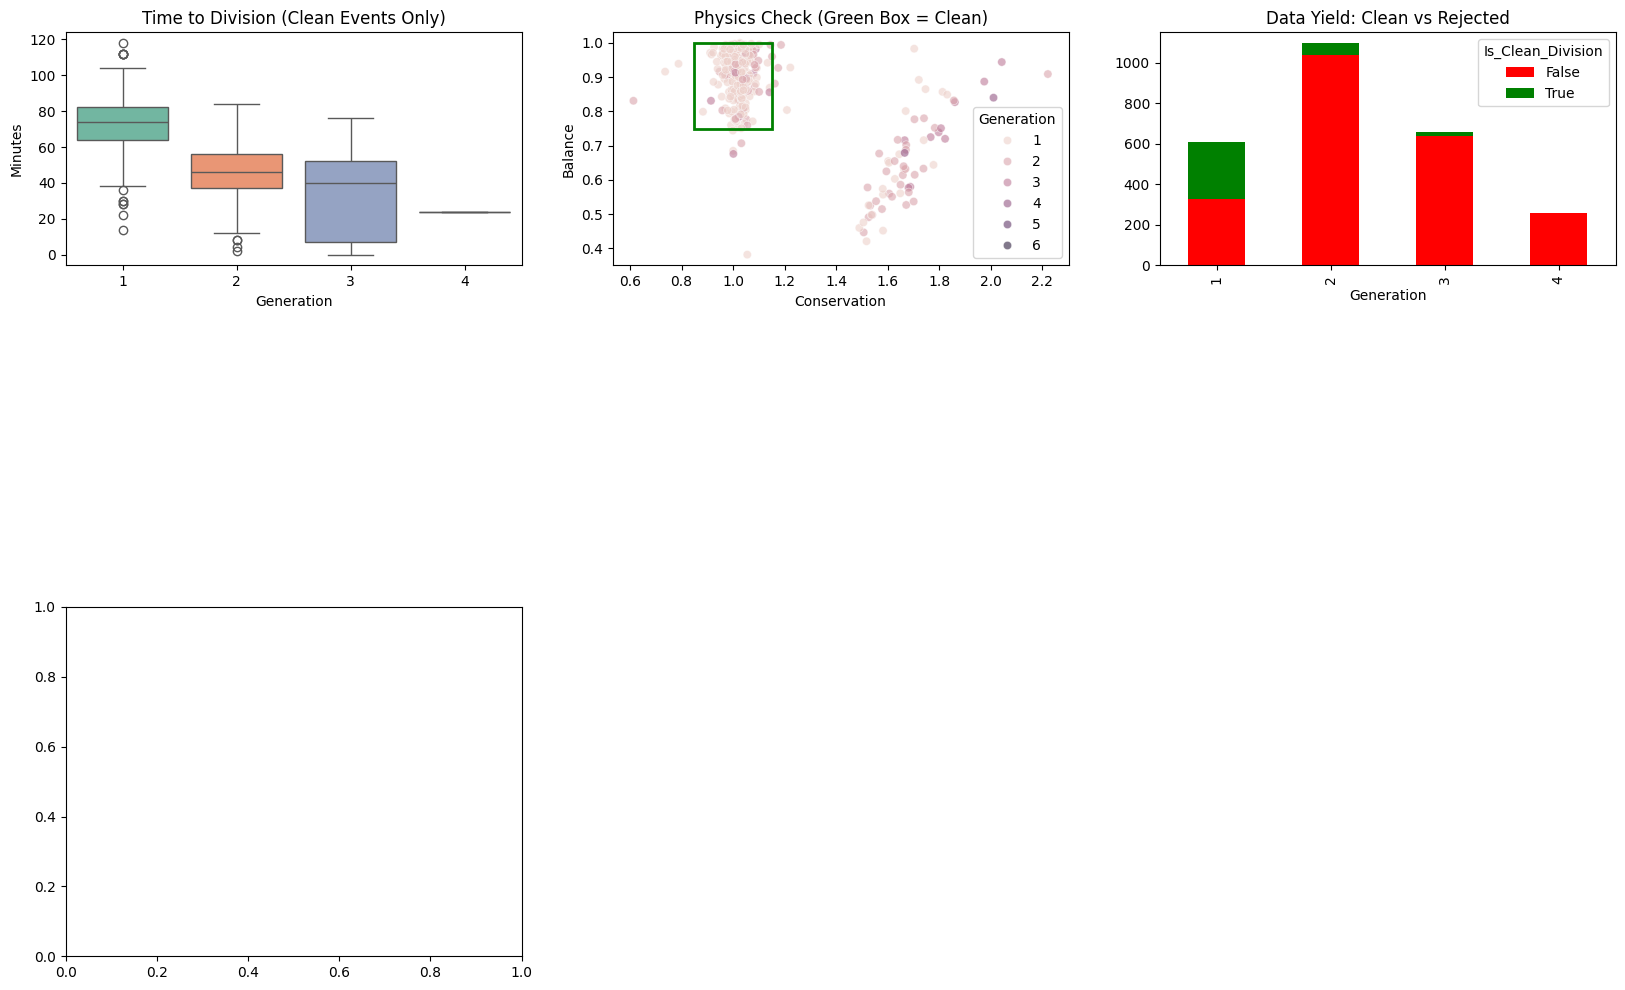

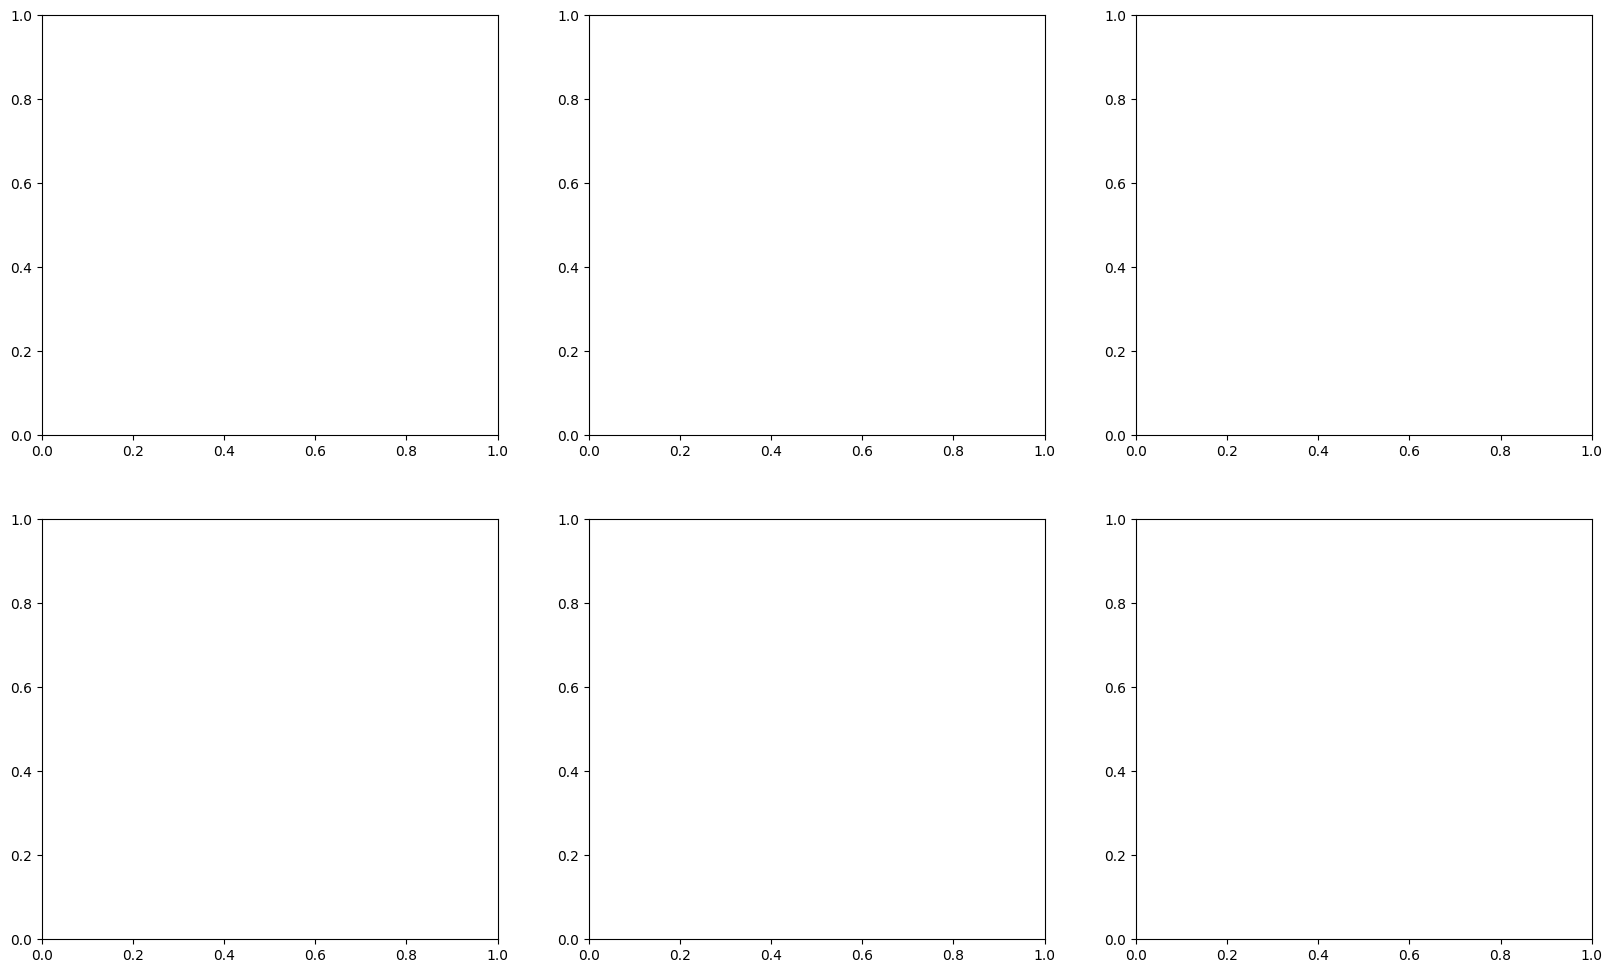

In [23]:
# 7.2 CORE QC DASHBOARD AND TREE VISUALS

if not ALL_BRANCHES_FILE.exists() or not ALL_LINEAGES_FILE.exists():
    print("⚠️ Skipped: combined CSVs not found.")
else:
    # Ensure directories exist
    qc_root = LINEAGE_DETAIL_ROOT / "Other_QC"
    dashboard_dir = qc_root / "dashboards"
    tree_gallery_dir = qc_root / "tree_gallery"
    tree_network_dir = qc_root / "tree_network"

    dashboard_dir.mkdir(parents=True, exist_ok=True)
    tree_gallery_dir.mkdir(parents=True, exist_ok=True)
    tree_network_dir.mkdir(parents=True, exist_ok=True)

    # Re-use in-memory data (or reload if needed)
    stats = combined_branches.copy()
    lineages = combined_branches.copy()  # if you keep a separate lineages DF, replace this
    lineage_paths = combined_paths.copy()

    # 1. Robust QC dashboard
    dashboard_file = dashboard_dir / "QC_Dashboard.png"
    try:
        plot_robust_dashboard(stats, lineages, dashboard_file)
        print(f"✅ Saved QC dashboard: {dashboard_file}")
    except Exception as e:
        print(f"⚠️ QC dashboard failed: {e}")

    # 2. Lineage tree gallery (example trees)
    tree_gallery_file = tree_gallery_dir / "Lineage_Tree_Gallery.png"
    try:
        plot_lineage_tree_gallery(
            lineage_paths,
            stats,
            lineages,
            tree_gallery_file,
            n_examples=MAX_LINEAGE_EXAMPLES
        )
        print(f"✅ Saved lineage tree gallery: {tree_gallery_file}")
    except Exception as e:
        print(f"⚠️ Lineage tree gallery failed: {e}")

    # 3. Network diagram (pick best root from combined paths)
    try:
        if not lineage_paths.empty:
            best_root = (
                lineage_paths.sort_values("PathLength", ascending=False)
                .iloc[0]["RootID"]
            )
            network_file = tree_network_dir / f"Lineage_Network_root_{best_root}.png"
            plot_lineage_tree_network(lineage_paths, stats, network_file, root_id=best_root)
            print(f"✅ Saved lineage network diagram: {network_file}")
        else:
            print("⚠️ No lineage paths available for network diagram.")
    except Exception as e:
        print(f"⚠️ Lineage network diagram failed: {e}")


⚠️ Detailed path plotting failed: 'BRANCH_ID'


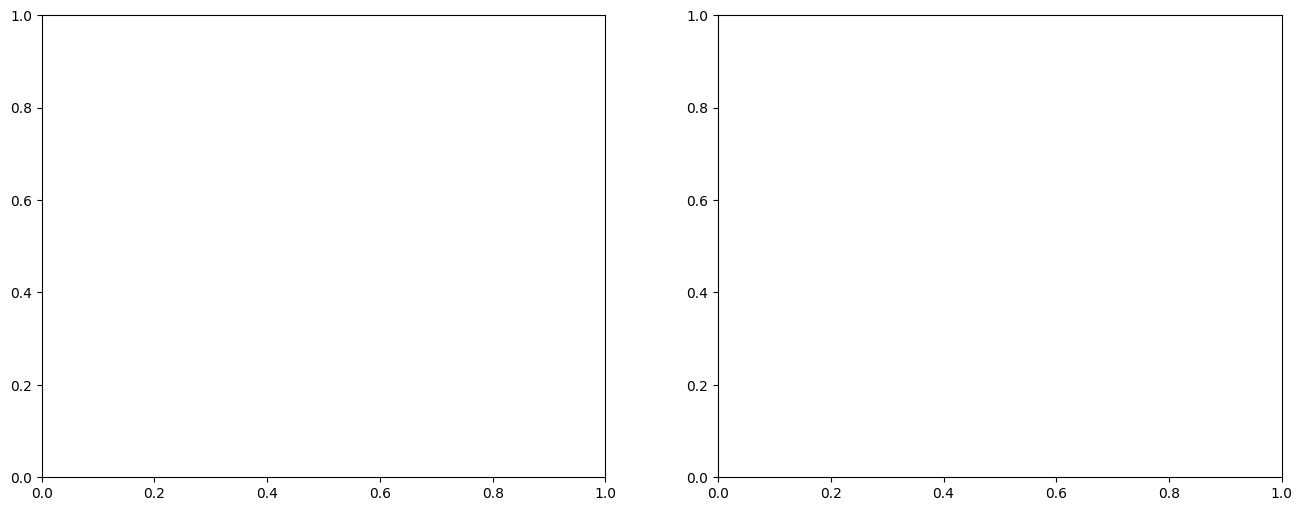

In [24]:
# 7.3 DETAILED LINEAGE PATH PLOTS (VERIFICATION)

if not ALL_BRANCHES_FILE.exists() or not ALL_LINEAGES_FILE.exists():
    print("⚠️ Skipped: combined CSVs not found.")
else:
    detail_root = LINEAGE_DETAIL_ROOT / "Plots_by_Generation"
    lineage_detail_dir = detail_root / "lineage_paths"
    lineage_detail_dir.mkdir(parents=True, exist_ok=True)

    stats = combined_branches.copy()
    lineages = combined_branches.copy()  # replace with your dedicated lineages DF if different
    lineage_paths = combined_paths.copy()

    try:
        plot_lineage_path_details(
            lineage_paths,
            stats,
            lineages,
            lineage_detail_dir,
            max_paths=MAX_DETAIL_PLOTS
        )
        print(f"✅ Saved detailed lineage path plots to: {lineage_detail_dir}")
    except Exception as e:
        print(f"⚠️ Detailed path plotting failed: {e}")


## 7.4 📊 Pipeline Step 2 – Multi-Condition Population Comparison

This section:

- Loads `Results/AllBranchesStats.csv` from Step 1.  
- Compares different biological conditions (e.g., genotypes, treatments).  
- Generates high-level plots (violin, ridge, CDF, etc.) and summary statistics.

All outputs are written to `Results/LineagePathDetails/Population_Comparisons/`.


In [25]:
# ═══════════════════════════════════════════════════════════════
# 📊 PIPELINE STEP 2: MULTI-CONDITION POPULATION COMPARISON
# ═══════════════════════════════════════════════════════════════
#
# INPUT:  Results/AllBranchesStats.csv (from Step 1)
# OUTPUT: Population comparison plots in:
#         Results/LineagePathDetails/Population_Comparisons/
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

MIN_GENERATION = 1
MAX_GENERATION = 3

EARTH_TONES = [
    "#264653",
    "#2A9D8F",
    "#E9C46A",
    "#F4A261",
    "#E76F51",
    "#6D597A",
    "#B56576",
    "#5F0F40"
]
sns.set_palette(EARTH_TONES)

print("\n--- PIPELINE STEP 2: MULTI-CONDITION POPULATION COMPARISON ---")

if not ALL_BRANCHES_FILE.exists():
    print("❌ AllBranchesStats.csv not found in Results/.")
    print("   Make sure you ran the batch processing section first.")
else:
    df = pd.read_csv(ALL_BRANCHES_FILE)
    print(f" Loaded: {ALL_BRANCHES_FILE.name}")
    print(f" Analyzing {len(df)} cells...")

    POP_ROOT = LINEAGE_DETAIL_ROOT / "Population_Comparisons"
    POP_ROOT.mkdir(parents=True, exist_ok=True)

    # ── 1. CONDITION DETECTION LOGIC ─────────────────────────
    def get_condition(filename):
        name_lower = filename.lower()
        shape_genes = {
            'mreb': 'MreB Mutant', 'mrec': 'MreC Mutant', 'mred': 'MreD Mutant',
            'roda': 'RodA Mutant', 'rodz': 'RodZ Mutant', 'mrda': 'MrdA (PBP2) Mutant',
            'pbp2': 'PBP2 Mutant', 'ftsz': 'FtsZ Mutant',
            'minc': 'MinC Mutant', 'mind': 'MinD Mutant', 'mine': 'MinE Mutant',
            'spot': 'spoT Mutant', 'nadr': 'NadR Mutant', 'topa': 'TopA Mutant',
            'rsfs': 'RsfS Mutant'
        }
        for gene, label in shape_genes.items():
            if gene in name_lower:
                return label
        if 'drug' in name_lower or 'treatment' in name_lower:
            return "Drug Treatment"
        if any(x in name_lower for x in ['wt', 'wild_type', 'wildtype', 'control']):
            return "Wild Type"
        if 'mutant' in name_lower or 'mut' in name_lower:
            return "Mutant"
        return f"Unknown ({filename[:15]}...)"

    # ── 2. HELPERS: OUTLIERS & STATS ─────────────────────────
    def remove_outliers(df_, column):
        if df_.empty or column not in df_.columns:
            return df_
        valid = df_.dropna(subset=[column])
        Q1 = valid[column].quantile(0.25)
        Q3 = valid[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        return valid[(valid[column] >= lower) & (valid[column] <= upper)]

    def cliffs_delta(x, y):
        from scipy.stats import mannwhitneyu
        x = np.asarray(x).flatten()
        y = np.asarray(y).flatten()
        nx, ny = len(x), len(y)
        if nx == 0 or ny == 0:
            return 0.0
        try:
            u_stat, _ = mannwhitneyu(x, y, alternative='two-sided')
            d = (2 * u_stat / (nx * ny)) - 1
            return abs(d)
        except:
            return 0.0

    def fdr_correction(p_values, alpha=0.05):
        p_values = np.asarray(p_values)
        if len(p_values) == 0:
            return []
        n = len(p_values)
        sorted_indices = np.argsort(p_values)
        sorted_p = p_values[sorted_indices]
        ranks = np.arange(1, n + 1)
        critical_vals = (ranks / n) * alpha
        below = sorted_p <= critical_vals
        if not np.any(below):
            return np.zeros(n, dtype=bool)
        k_max_idx = np.max(np.where(below)[0])
        reject_sorted = np.zeros(n, dtype=bool)
        reject_sorted[:k_max_idx + 1] = True
        reject = np.zeros(n, dtype=bool)
        reject[sorted_indices] = reject_sorted
        return reject

    def get_effect_star(is_significant, d):
        if not is_significant:
            return ""
        if d < 0.147:
            return ""
        if d >= 0.474:
            return "****"
        if d >= 0.33:
            return "***"
        if d >= 0.147:
            return "*"
        return ""

    def run_stats_and_annotate(ax, data, x_col, y_col, hue_col, order, hue_order):
        cond_col = None
        wt_name = None
        search_cols = [hue_col, x_col] if hue_col else [x_col]
        for col in search_cols:
            if col not in data.columns:
                continue
            if data[col].dtype == object or pd.api.types.is_string_dtype(data[col]):
                unique_vals = data[col].astype(str).unique()
                potential_wt = next(
                    (c for c in unique_vals
                     if "wild" in c.lower() or "wt" in c.lower() or "control" in c.lower()),
                    None
                )
                if potential_wt:
                    cond_col = col
                    wt_name = potential_wt
                    break
        if not wt_name:
            return

        comparisons = []
        if cond_col == x_col:
            wt_group = data[data[x_col] == wt_name]
            for x_cat in order:
                if str(x_cat) == str(wt_name):
                    continue
                current_hues = hue_order if hue_col else [None]
                for hue_val in current_hues:
                    mask_mut = (data[x_col] == x_cat)
                    if hue_val is not None:
                        mask_mut &= (data[hue_col] == hue_val)
                    mut_vals = data.loc[mask_mut, y_col].dropna()
                    mask_wt = pd.Series(True, index=wt_group.index)
                    if hue_val is not None:
                        mask_wt &= (wt_group[hue_col] == hue_val)
                    wt_vals = wt_group.loc[mask_wt, y_col].dropna()
                    if len(mut_vals) > 3 and len(wt_vals) > 3:
                        comparisons.append({
                            "x": x_cat,
                            "hue": hue_val,
                            "mut": mut_vals.values,
                            "wt": wt_vals.values,
                        })
        else:
            for x_cat in order:
                subset = data[data[x_col] == x_cat]
                wt_vals = subset[subset[hue_col] == wt_name][y_col].dropna()
                if len(wt_vals) < 3:
                    continue
                for hue_val in hue_order:
                    if str(hue_val) == str(wt_name):
                        continue
                    mut_vals = subset[subset[hue_col] == hue_val][y_col].dropna()
                    if len(mut_vals) > 3:
                        comparisons.append({
                            "x": x_cat,
                            "hue": hue_val,
                            "mut": mut_vals.values,
                            "wt": wt_vals.values,
                        })
        if not comparisons:
            return

        p_values = []
        deltas = []
        for comp in comparisons:
            try:
                _, p = stats.mannwhitneyu(comp["mut"], comp["wt"], alternative="two-sided")
                d = cliffs_delta(comp["mut"], comp["wt"])
                p_values.append(p)
                deltas.append(d)
            except:
                p_values.append(1.0)
                deltas.append(0.0)

        is_significant = fdr_correction(p_values, alpha=0.05)

        n_hues = len(hue_order) if hue_order else 1
        width = 0.8
        if hue_order and n_hues > 1:
            step = width / n_hues
            offsets = np.linspace(-width / 2 + step / 2, width / 2 - step / 2, n_hues)
            hue_offset_map = dict(zip(hue_order, offsets))
        else:
            hue_offset_map = {None: 0}

        y_range = data[y_col].max() - data[y_col].min()
        for i, comp in enumerate(comparisons):
            star = get_effect_star(is_significant[i], deltas[i])
            if star:
                x_base = order.index(comp["x"])
                x_shift = hue_offset_map.get(comp["hue"], 0)
                x_pos = x_base + x_shift
                y_pos = np.max(comp["mut"]) + (y_range * 0.05)
                color = "#D62828" if len(star) == 4 else "black"
                ax.text(
                    x_pos, y_pos, star,
                    ha="center", va="bottom",
                    fontsize=8, fontweight="bold", color=color,
                )

    # ── 3. PLOTTING FUNCTIONS ────────────────────────────────
    def get_sorted_order(df_, col='Condition'):
        if df_.empty or col not in df_.columns:
            return []
        valid_data = df_[col].dropna()
        wt_match = next((x for x in sorted(valid_data.astype(str).unique()) if x.lower() in ['wild type', 'wild_type', 'wt']), None)
        if wt_match:
            sorted(valid_data.astype(str).unique()).remove(wt_match)
            sorted(valid_data.astype(str).unique()).insert(0, wt_match)
        return sorted(valid_data.astype(str).unique())

    def plot_lineage_memory(df, out_path):
        """
        Correlates Mother vs Daughter Duration.
        RESTRICTED TO: Gen 1 (Mother) -> Gen 2 (Daughter) only.
        """
        merged = pd.merge(df, df, left_on='Cell_ID', right_on='Parent_ID', suffixes=('_M', '_D'))

        # 1. Filter for Clean Divisions
        if 'Is_Clean_Division_M' in merged.columns and 'Is_Clean_Division_D' in merged.columns:
            clean = merged[(merged['Is_Clean_Division_M'] == True) &
                          (merged['Is_Clean_Division_D'] == True)].copy()
        else:
            clean = merged.copy()

        # 2. RESTRICT GENERATION: Only keep Gen 1 Mothers
        # This prevents sample size explosion from later generations
        clean = clean[clean['Generation_M'] == 1]

        # 3. Remove Outliers
        clean = remove_outliers(clean, 'Duration_M')
        clean = remove_outliers(clean, 'Duration_D')
        clean['Condition'] = clean['Condition_M']

        if clean.empty:
            print("   ⚠️ Not enough Gen 1 mother-daughter pairs for memory plot.")
            return

        # 4. Plot
        g = sns.lmplot(data=clean, x='Duration_M', y='Duration_D', hue='Condition',
                      col='Condition', col_wrap=3, height=5, aspect=1,
                      scatter_kws={'alpha':0.5, 's':20}, line_kws={'lw':2}, sharex=False, sharey=False)

        for ax, (cond, subset) in zip(g.axes.flat, clean.groupby('Condition')):
            if len(subset) > 5:
                r, p = stats.pearsonr(subset['Duration_M'], subset['Duration_D'])
                ax.text(0.05, 0.9, f'r={r:.2f}\np={p:.3f}\nN={len(subset)}', transform=ax.transAxes,
                      fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))
            ax.set_title(f"{cond} (Gen 1 -> Gen 2)")

        plt.subplots_adjust(top=0.9)
        g.fig.suptitle("LINEAGE MEMORY: Heritability (First Generation Only)", y=0.98, fontsize=16, fontweight='bold')
        plt.savefig(out_path / "1_Lineage_Memory_Gen1.png", dpi=150, bbox_inches='tight')
        plt.close()

    def plot_sister_asymmetry(df, out_path):
        """
        Compare sisters (A vs B) from the same mother.
        Updates legend with N counts.
        """
        daughters = df[df['Parent_ID'].notna()]
        sisters = pd.merge(daughters, daughters, on='Parent_ID', suffixes=('_A', '_B'))
        sisters = sisters[sisters['Cell_ID_A'] < sisters['Cell_ID_B']].copy()

        df['Unique_ID'] = df['Source_File'].astype(str) + "_" + df['Cell_ID'].astype(str)
        parent_clean_lookup = df.set_index('Unique_ID')['Is_Clean_Division'].to_dict()

        sisters['Unique_Parent_ID'] = sisters['Source_File_A'].astype(str) + "_" + sisters['Parent_ID'].astype(str)
        sisters['Parent_Is_Clean'] = sisters['Unique_Parent_ID'].map(parent_clean_lookup)

        clean_sisters = sisters[sisters['Parent_Is_Clean'] == True].copy()
        if clean_sisters.empty: return

        clean_sisters['Condition'] = clean_sisters['Condition_A']
        clean_sisters['Dur_Diff'] = abs(clean_sisters['Duration_A'] - clean_sisters['Duration_B'])
        clean_sisters = remove_outliers(clean_sisters, 'Dur_Diff')
        cond_order = get_sorted_order(clean_sisters)

        counts = clean_sisters['Condition'].value_counts().to_dict()

        plt.figure(figsize=(10, 7))
        ax = sns.ecdfplot(data=clean_sisters, x='Dur_Diff', hue='Condition',
                          hue_order=cond_order, linewidth=2, palette=EARTH_TONES)

        plt.title("SISTER ASYMMETRY: Synchrony of Division", fontsize=14, fontweight='bold')
        plt.xlabel("Absolute Difference in Division Time (Frames)")
        handles, _ = ax.get_legend_handles_labels()
        new_labels = [f"{cond} (N={counts.get(cond, 0)} valid)" for cond in cond_order]

        plt.legend(handles, new_labels, title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.subplots_adjust(right=0.75, bottom=0.15)
        plt.savefig(out_path / "2_Sister_Asymmetry_Duration.png", dpi=150)
        plt.close()

    def plot_size_control(df, out_path):
        """
        Adder vs Timer vs Sizer Analysis (Slope of Added vs Birth Size).
        Updates legend with N counts.
        """
        req_cols = ['Start_Area', 'End_Area']
        if not all(c in df.columns for c in req_cols): return

        df['Added_Area'] = df['End_Area'] - df['Start_Area']
        valid = df[df['Added_Area'] > 0].copy()

        if 'Is_Clean_Division' in valid.columns:
            clean = valid[valid['Is_Clean_Division'] == True].copy()
        else:
            clean = valid.copy()

        clean = remove_outliers(clean, 'Start_Area')
        clean = remove_outliers(clean, 'Added_Area')

        if clean.empty: return

        counts = clean['Condition'].value_counts()
        # Create a mapping: "Wild Type" -> "Wild Type (N=150)"
        clean['Condition'] = clean['Condition'].apply(lambda x: f"{x} (N={counts.get(x, 0)} valid)")

        g = sns.lmplot(data=clean, x='Start_Area', y='Added_Area', hue='Condition',
                      col='Condition',col_wrap=3, height=4, aspect=1.2,
                      scatter_kws={'alpha':0.4, 's':20}, line_kws={'lw':2, 'color':'black'}, sharex=False, sharey=False)

        for ax, (cond, subset) in zip(g.axes.flat, clean.groupby('Condition')):
            if len(subset) > 5:
                slope, _, r_val, _, _ = stats.linregress(subset['Start_Area'], subset['Added_Area'])
                if -0.3 <= slope <= 0.3: mode = "ADDER"
                elif slope > 0.7: mode = "TIMER"
                elif slope < -0.7: mode = "SIZER"
                else: mode = "MIXED"
                ax.text(0.05, 0.85, f'Slope={slope:.2f}\nR²={r_val**2:.2f}\n{mode}', transform=ax.transAxes,
                      fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))
            ax.set_title(f"{cond}")

        plt.subplots_adjust(top=0.9)
        g.fig.suptitle("SIZE CONTROL HOMEOSTASIS", y=0.98, fontsize=16, fontweight='bold')

        plt.savefig(out_path / "3_Size_Control.png", dpi=150, bbox_inches='tight')
        plt.close()

    def plot_geometry_comparisons(df, out_path):
        """
        Generates comparison plots for all available geometric metrics.
        Includes N counts in legend and moves legend outside.
        """
        df_gen = df[(df['Generation'] >= MIN_GENERATION) &
                    (df['Generation'] <= MAX_GENERATION)].copy()

        if 'Is_Clean_Division' in df_gen.columns:
            df_gen = df_gen[df_gen['Is_Clean_Division'] == True]

        if 'Mean_AR' not in df_gen.columns and 'Mean_Major' in df_gen.columns:
            df_gen['Mean_AR'] = df_gen['Mean_Major'] / np.maximum(df_gen['Mean_Minor'], 1e-9)

        metrics = [
            ('Mean_Major', 'Length (μm)', 'Cell Length'),
            ('Mean_Minor', 'Width (μm)', 'Cell Width'),
            ('Mean_AR', 'Aspect Ratio', 'Aspect Ratio'),
            ('Mean_Area', 'Area (px²)', 'Cell Area'),
            ('Growth_Rate_k_min', 'Specific Rate k (min⁻¹)', 'Specific Growth Rate'),
            ('Doubling_Time_min', 'Minutes', 'Doubling Time'),
            ('Duration_Minutes', 'Minutes', 'Division Duration (Min)'),
            ('Mean_Perimeter', 'Perimeter (μm)', 'Cell Perimeter'),
            ('Mean_Circularity', 'Circularity (0-1)', 'Cell Circularity'),
            ('Mean_Solidity', 'Solidity (0-1)', 'Cell Solidity'),
            ('Mean_Shape_Index', 'Shape Index', 'Shape Index'),
            ('Mean_Angle', 'Angle (Radians)', 'Orientation Angle')
        ]

        cond_order = get_sorted_order(df_gen)

        for i, (col, ylabel, title) in enumerate(metrics):
            if col not in df_gen.columns: continue

            clean_data = remove_outliers(df_gen, col)
            if clean_data.empty: continue

            # Calculate N for this specific metric after cleaning
            counts = clean_data['Condition'].value_counts().to_dict()

            plt.figure(figsize=(10, 7))

            # Plot (keep original names for color mapping consistency)
            ax = sns.stripplot(data=clean_data, x='Generation', y=col, hue='Condition',
                          hue_order=cond_order, palette=EARTH_TONES,
                          dodge=True, alpha=0.7, size=4, jitter=0.25, zorder=0)

            sns.boxplot(data=clean_data, x='Generation', y=col, hue='Condition',
                        hue_order=cond_order, palette=EARTH_TONES,
                        showfliers=False, boxprops={'alpha': 0.6, 'edgecolor': 'black'}, zorder=10)

            run_stats_and_annotate(ax, clean_data, 'Generation', col, 'Condition',
                                  sorted(clean_data['Generation'].unique()), cond_order)

            # --- LEGEND MODIFICATION ---
            handles, _ = ax.get_legend_handles_labels()
            # Create new labels with N counts, preserving the order of 'cond_order'
            new_labels = [f"{cond} (N={counts.get(cond, 0)} valid)" for cond in cond_order]

            # Slice handles to match condition count (avoid duplicates from strip+box)
            if handles:
                plt.legend(handles[:len(cond_order)], new_labels, title='Condition',
                          bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
            # ---------------------------

            plt.title(f"{title}", fontweight='bold')
            plt.ylabel(ylabel)

            # Adjust layout to make room for external legend
            plt.subplots_adjust(right=0.75, bottom=0.15)
            plt.savefig(out_path / f"4{chr(97+i)}_{title.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
            plt.close()


    def plot_boss_three_point_geometry(df, out_path):
        """
        Advanced 'Boss Plot': Tracks geometry across Birth -> Division -> Daughter.
        - Removes 'WithOutliers' version (plots only Clean data).
        - Uses original condition names on X-axis (fixes stats alignment).
        - Adds a SECOND legend for N counts.
        """
        print("    -> Plotting Boss Three-Point Geometry...")
        base_features = set()
        for col in df.columns:
            if col.startswith('Start_') and f'End_{col[6:]}' in df.columns:
                base_features.add(col[6:])

        if not base_features: return

        # Build linkage
        start_values = df.set_index(['Source_File', 'Cell_ID']).to_dict(orient='index')

        df_linked = df.copy()
        daughters_map = {}
        for _, row in df[df['Parent_ID'].notna()].iterrows():
            key = (row['Source_File'], row['Parent_ID'])
            if key not in daughters_map: daughters_map[key] = []
            daughters_map[key].append(row['Cell_ID'])

        for feature in base_features:
            col_linked = f'Linked_Daughter_Start_{feature}'
            linked_vals = []
            for _, row in df_linked.iterrows():
                children = daughters_map.get((row['Source_File'], row['Cell_ID']), [])
                vals = []
                for child in children:
                    key = (row['Source_File'], child)
                    if key in start_values:
                        val = start_values[key].get(f'Start_{feature}', np.nan)
                        if pd.notna(val): vals.append(val)
                linked_vals.append(np.median(vals) if vals else np.nan)
            df_linked[col_linked] = linked_vals

        df_clean = df_linked[df_linked['Is_Clean_Division'] == True].copy()
        if df_clean.empty: return
        cond_order = get_sorted_order(df)

        for feature in sorted(base_features):
            col_s, col_e = f'Start_{feature}', f'End_{feature}'
            col_l = f'Linked_Daughter_Start_{feature}'

            if df_clean[col_l].isna().all(): continue

            melted = df_clean.melt(id_vars=['Condition'], value_vars=[col_s, col_e, col_l],
                                  var_name='Stage', value_name='Value')
            melted['Stage'] = melted['Stage'].map({col_s:'1. Birth', col_e:'2. Division', col_l:'3. Daughter'})

            # ONLY Run 'NoOutliers' Version
            plot_data = melted.groupby(['Condition', 'Stage']).apply(lambda x: remove_outliers(x, 'Value')).reset_index(drop=True)
            if plot_data.empty: continue

            # --- CALCULATE N COUNTS ---
            n_counts = plot_data[plot_data['Stage'] == '1. Birth']['Condition'].value_counts().to_dict()

            plt.figure(figsize=(16, 14))

            # PLOT (Use original 'Condition' column and 'cond_order' to ensure alignment)
            ax = sns.stripplot(data=plot_data, x='Condition', y='Value', hue='Stage',
                          order=cond_order, palette=["#2A9D8F", "#E76F51", "#264653"],
                          dodge=True, jitter=True, size=3, alpha=0.4)

            sns.boxplot(data=plot_data, x='Condition', y='Value', hue='Stage',
                        order=cond_order, palette=["#2A9D8F", "#E76F51", "#264653"],
                        dodge=True, showfliers=False, width=0.8)

            # STATS (Will now align perfectly because x-axis matches cond_order)
            run_stats_and_annotate(ax, plot_data, 'Condition', 'Value', 'Stage', cond_order, ['1. Birth', '2. Division', '3. Daughter'])

            # --- LEGEND 1: STAGES ---
            handles, labels = ax.get_legend_handles_labels()
            # Keep only the first 3 (Birth, Div, Daughter)
            leg1 = plt.legend(handles[:3], labels[:3], title='Cell Cycle Stage',
                      bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., markerscale=4.0)
            ax.add_artist(leg1) # Add back because the next legend call would wipe it

            # --- LEGEND 2: N COUNTS ---
            # Create invisible patches to serve as legend entries
            import matplotlib.patches as mpatches
            n_handles = [mpatches.Patch(color='none', label=f"{c}: N={n_counts.get(c,0)}") for c in cond_order]

            plt.legend(handles=n_handles, title='Sample Sizes (Cells)',
                      bbox_to_anchor=(1.02, 0.75), loc='upper left', frameon=False)

            plt.title(f"Cell {feature} Cycle", fontweight='bold', fontsize=14)
            plt.xticks(rotation=45, ha='right')
            # --- ADDING TEXT BELOW FIGURE ---
            stats_description = (
                "Statistical Significance (Cliff's Delta Effect Size):\n"
                "* : Small Effect (d > 0.147)\n"
                "*** : Medium Effect (d > 0.33)\n"
                "**** : Large Effect (d > 0.474)\n\n"
                "This plot tracks individual cell lineages across three key timepoints:\n"
                "1. Birth: Size immediately after mother divides.\n"
                "2. Division: Size of the same cell just before it divides.\n"
                "3. Daughter: Birth size of this cell's offspring (checking for size resetting)."
            )

            # Adjust bottom margin to make space
            plt.subplots_adjust(bottom=0.25, right=0.80)

            # Place text in figure coordinates
            plt.figtext(0.80, 0.02, stats_description, ha="center", fontsize=12,
                        bbox={"facecolor":"#f0f0f0", "alpha":0.5, "pad":10, "edgecolor":"gray"})
            # --------------------------------

            plt.savefig(out_path / f"ThreePoint_{feature}_NoOutliers.png", dpi=150)
            plt.close()

    def plot_boss_division_timing(df, out_path):
        """
        Plots time to 1st, 2nd, 3rd division (Clean Data Only).
        - Adds N counts to separate legend.
        - Adds descriptive text box at bottom right.
        """
        print("    -> Plotting Division Timing...")
        sub = df[df['Generation'].between(1, 3)].copy()
        if 'Is_Clean_Division' in sub.columns:
            sub = sub[sub['Is_Clean_Division'] == True]

        if sub.empty: return
        cond_order = get_sorted_order(df)

        # ONLY Run 'NoOutliers' Version
        plot_data = sub.groupby(['Condition', 'Generation']).apply(lambda x: remove_outliers(x, 'Duration_Minutes')).reset_index(drop=True)

        if plot_data.empty: return

        # --- CALCULATE N COUNTS (Based on Gen 1) ---
        n_counts = plot_data[plot_data['Generation'] == 1]['Condition'].value_counts().to_dict()

        plt.figure(figsize=(16, 10))

        # PLOT
        ax = sns.stripplot(data=plot_data, x='Condition', y='Duration_Minutes', hue='Generation',
                      order=cond_order, palette='viridis', dodge=True, jitter=True, size=3, alpha=0.4)

        sns.boxplot(data=plot_data, x='Condition', y='Duration_Minutes', hue='Generation',
                    order=cond_order, palette='viridis', dodge=True, showfliers=False, width=0.8)

        # STATS
        run_stats_and_annotate(ax, plot_data, 'Condition', 'Duration_Minutes', 'Generation', cond_order, [1, 2, 3])

        # --- LEGEND 1: GENERATIONS ---
        handles, labels = ax.get_legend_handles_labels()
        # Keep only 3 entries (Gen 1, 2, 3)
        leg1 = plt.legend(handles[:3], labels[:3], title='Generation',
                  bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., markerscale=4.0)
        ax.add_artist(leg1)

        # --- LEGEND 2: N COUNTS ---
        import matplotlib.patches as mpatches
        n_handles = [mpatches.Patch(color='none', label=f"{c}: N={n_counts.get(c,0)}") for c in cond_order]

        plt.legend(handles=n_handles, title='Sample Sizes (Gen 1)',
                  bbox_to_anchor=(1.02, 0.75), loc='upper left', frameon=False)

        plt.title(f"Division Timing", fontweight='bold', fontsize=14)
        plt.ylabel("Time to Division (Minutes)")
        plt.xticks(rotation=45, ha='right')

        # --- ADDING TEXT BELOW FIGURE ---
        stats_description = (
            "Statistical Significance (Cliff's Delta Effect Size):\n"
            "* : Small Effect (d > 0.147)\n"
            "*** : Medium Effect (d > 0.33)\n"
            "**** : Large Effect (d > 0.474)\n\n"
            "This plot compares the division duration across the first 3 generations:\n"
            "Gen 1: Initial cells present at start of movie.\n"
            "Gen 2: First generation of daughters born in the movie.\n"
            "Gen 3: Granddaughters (checking for trans-generational stability)."
        )

        # Adjust margins: bottom=0.25 (text), right=0.80 (legend)
        plt.subplots_adjust(bottom=0.25, right=0.80)

        # Place text in bottom-right corner
        plt.figtext(0.98, 0.02, stats_description, ha="right", fontsize=10,
                    bbox={"facecolor":"#f0f0f0", "alpha":0.5, "pad":10, "edgecolor":"gray"})
        # --------------------------------

        plt.savefig(out_path / f"Time_to_Division_NoOutliers.png", dpi=150)
        plt.close()


    def generate_boss_summary_table(df, out_path):
        """Summarizes key metrics per condition into a CSV."""
        stats_list = []
        for cond in df['Condition'].unique():
            sub = df[df['Condition'] == cond]
            k_max = sub['Max_Instant_k_min'].median() if 'Max_Instant_k_min' in sub.columns else np.nan
            t1 = sub[sub['Generation'] == 1]['Duration_Minutes'].median()
            stats_list.append({
                'Condition': cond, 'Max_Growth_Rate': round(k_max, 4),
                'Time_Div_1': round(t1, 1), 'N_Cells': len(sub)
            })
        pd.DataFrame(stats_list).to_csv(out_path / "Boss_Summary_Table.csv", index=False)


    def identify_non_dividers_lineage(df):
        """
        Cells that never become parents = non-dividers.
        Most direct method if tracking is accurate.
        """
        # Get all cells that appear as parents (filtering for valid IDs)
        dividing_cells = set(df[df['Parent_ID'].notna()]['Parent_ID'].unique())

        # All unique cells in the dataset
        all_cells = set(df['Cell_ID'].unique())

        # Non-dividers = cells that never appear as parents
        non_dividers = all_cells - dividing_cells

        # Mark in dataframe
        df['Is_Non_Divider'] = df['Cell_ID'].isin(non_dividers)

        return df

    def plot_non_dividers(df, out_path):
        """
        Plots frequency of cells that never divided (never became parents).
        Uses ONLY lineage information (simplest method).
        """
        # 1. Tag non-dividers
        df_tagged = identify_non_dividers_lineage(df.copy())

        # 2. Group by Condition to get counts
        # 'sum' counts True values (Non-Dividers), 'count' gets total cells
        summary = df_tagged.groupby('Condition')['Is_Non_Divider'].agg(['sum', 'count']).reset_index()
        summary.rename(columns={'sum': 'Non_Dividers', 'count': 'Total_Cells'}, inplace=True)

        # Calculate Percentage
        summary['Percent_Non_Dividers'] = (summary['Non_Dividers'] / summary['Total_Cells']) * 100

        # 3. Sort (Wild Type first)
        cond_order = get_sorted_order(df_tagged)
        summary['Condition'] = pd.Categorical(summary['Condition'], categories=cond_order, ordered=True)
        summary = summary.sort_values('Condition')

        # 4. Plot
        plt.figure(figsize=(10, 7))
        bars = plt.bar(summary['Condition'], summary['Percent_Non_Dividers'], color=EARTH_TONES[:len(summary)])

        # Add count labels on top of bars: "5/100"
        for bar, (_, row) in zip(bars, summary.iterrows()):
            height = bar.get_height()
            label_text = f"{int(row['Non_Dividers'])}/{int(row['Total_Cells'])}"
            plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, label_text,
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

        plt.ylabel("% Cells That Did Not Divide")
        plt.title("Frequency of Non-Dividing Cells (Lineage Based)", fontweight='bold')
        plt.xticks(rotation=45, ha='right')

        plt.tight_layout()
        plt.savefig(out_path / "Non_Dividers_Lineage_Only.png", dpi=150)
        plt.close()

        print(f"   -> Non-divider plot saved to {out_path / 'Non_Dividers_Lineage_Only.png'}")


    def plot_true_non_dividers_duration_aware(df, out_path):
        """
        Identifies non-dividers based on Opportunity Time.

        Definition of True Non-Divider:
        1. Has NO children.
        2. Was tracked for longer than the typical doubling time (e.g., > 1.5x Median Doubling Time).
          This ensures we don't count short/broken tracks as non-dividers.
        """
        print("   -> Classifying Non-Dividers using Duration Threshold...")

        # 1. Calculate Typical Doubling Time per Condition (Robust Median)
        # We only look at cells that DID divide to find the "normal" time.
        dividers = df[df['Parent_ID'].notna()] # These are daughters, their 'Duration_Minutes' is generation time

        median_gen_times = dividers.groupby('Condition')['Duration_Minutes'].median().to_dict()

        # Fallback for conditions with no divisions (unlikely, but safe)
        global_median = dividers['Duration_Minutes'].median() if not dividers.empty else 30.0

        # 2. Identify Parents (Set of IDs)
        parent_ids = set(df[df['Parent_ID'].notna()]['Parent_ID'].unique())

        # 3. Classify Every Unique Cell
        # We need one row per cell with its Duration and Condition
        # Assuming 'Duration_Minutes' is total track length for that cell
        unique_cells = df[['Condition', 'Cell_ID', 'Duration_Minutes']].drop_duplicates()

        results = []

        for row in unique_cells.itertuples():
            cond = row.Condition
            dur = row.Duration_Minutes
            cid = row.Cell_ID

            # Threshold: How long must a cell persist to be called a "Non-Divider"?
            # Let's say 1.5x the median doubling time for that condition.
            # If normal is 40min, you must survive 60min without kids to count.
            threshold = median_gen_times.get(cond, global_median) * 1.5

            if cid in parent_ids:
                status = "Divider"
            else:
                # It has no children. Did we watch it long enough?
                if dur > threshold:
                    status = "True Non-Divider" # Long track, no kids. Real signal.
                else:
                    status = "Indeterminate" # Short track, no kids. Could be noise. Ignore.

            results.append({'Condition': cond, 'Status': status})

        classified_df = pd.DataFrame(results)

        # 4. Plotting
        # Filter out Indeterminate
        valid = classified_df[classified_df['Status'] != 'Indeterminate']

        summary = valid.groupby('Condition')['Status'].value_counts().unstack(fill_value=0)

        # Handle cases where columns might be missing
        if 'True Non-Divider' not in summary.columns: summary['True Non-Divider'] = 0
        if 'Divider' not in summary.columns: summary['Divider'] = 0

        summary['Total_Valid'] = summary['Divider'] + summary['True Non-Divider']
        summary['Percent_Non_Dividers'] = (summary['True Non-Divider'] / summary['Total_Valid']) * 100

        # Sort
        summary = summary.reset_index()
        cond_order = get_sorted_order(df)
        summary['Condition'] = pd.Categorical(summary['Condition'], categories=cond_order, ordered=True)
        summary = summary.sort_values('Condition')

        # Plot
        plt.figure(figsize=(10, 7))
        bars = plt.bar(summary['Condition'], summary['Percent_Non_Dividers'], color=EARTH_TONES[:len(summary)])

        for bar, (_, row) in zip(bars, summary.iterrows()):
            height = bar.get_height()
            # Label: "N_NonDiv / Total_Evaluated"
            label = f"{int(row['True Non-Divider'])}/{int(row['Total_Valid'])}"
            plt.text(bar.get_x() + bar.get_width()/2, height + (height*0.05), label,
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        plt.ylabel("% Long-Lived Cells That Did Not Divide")
        plt.title("Frequency of Non-Dividing Cells (Duration > 1.5x GenTime)", fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        description = (
            "Definition of True Non-Divider:\n"
            "1. Cell has NO children (never becomes a parent).\n"
            "2. Track Duration > 1.5x Median Generation Time for that condition.\n"
            "(Short tracks with no children are excluded as 'Indeterminate' to remove tracking noise.)"
        )
        plt.subplots_adjust(bottom=0.25)

        # Place text in figure coordinates (0,0 is bottom-left, 1,1 is top-right)
        plt.figtext(0.5, 0.02, description, ha="center", fontsize=10,
                    bbox={"facecolor":"orange", "alpha":0.1, "pad":5})
        plt.savefig(out_path / "Non_Dividers_Duration_Aware.png", dpi=150)
        plt.close()

        # Save the raw data so you can inspect WHO the non-dividers are
        classified_df.to_csv(out_path / "Non_Divider_Classification_List.csv", index=False)

        # ── 4. PREPARE DATA AND RUN PLOTS ───────────────────────

        # Ensure a 'Condition' column exists; if not, infer from filename or metadata
        if "Condition" not in df.columns:
            if "Source_File" in df.columns:
                df["Condition"] = df["Source_File"].astype(str).apply(get_condition)
            else:
                df["Condition"] = "Unknown"

        # Basic generation filter, if applicable
        if "Generation" in df.columns:
            df = df[(df["Generation"] >= MIN_GENERATION) & (df["Generation"] <= MAX_GENERATION)]

        print(f" -> Using {len(df)} rows after generation filtering "
              f"({MIN_GENERATION}–{MAX_GENERATION})")

        print(f"\nAnalyzing {len(df)} cells across "
              f"{df['Condition'].nunique() if 'Condition' in df.columns else 'N/A'} conditions...")

        print(" -> Plotting lineage memory (Gen 1 -> Gen 2)...")
        try:
            plot_lineage_memory(df.copy(), POP_ROOT)
        except Exception as e:
            print(f"   ⚠️ Lineage memory plot failed: {e}")

        print(" -> Plotting sister asymmetry...")
        try:
            plot_sister_asymmetry(df.copy(), POP_ROOT)
        except Exception as e:
            print(f"   ⚠️ Sister asymmetry plot failed: {e}")

        print(" -> Plotting size control (Adder/Timer/Sizer)...")
        try:
            plot_size_control(df.copy(), POP_ROOT)
        except Exception as e:
            print(f"   ⚠️ Size control plot failed: {e}")

        print(" -> Plotting geometry comparisons...")
        try:
            plot_geometry_comparisons(df.copy(), POP_ROOT)
        except Exception as e:
            print(f"   ⚠️ Geometry comparison plots failed: {e}")

        print(" -> Plotting three-point geometry (Boss plots)...")
        try:
            plot_boss_three_point_geometry(df.copy(), POP_ROOT)
        except Exception as e:
            print(f"   ⚠️ Boss three-point plots failed: {e}")

        print(" -> Plotting division timing distributions...")
        try:
            plot_boss_division_timing(df.copy(), POP_ROOT)
        except Exception as e:
            print(f"   ⚠️ Division timing plot failed: {e}")

        print(" -> Generating Boss summary table...")
        try:
            generate_boss_summary_table(df.copy(), POP_ROOT)
        except Exception as e:
            print(f"   ⚠️ Boss summary table failed: {e}")

        print(f"\n✅ Comparisons complete! Results saved to: {POP_ROOT}")



--- PIPELINE STEP 2: MULTI-CONDITION POPULATION COMPARISON ---
 Loaded: AllBranchesStats.csv
 Analyzing 2699 cells...


## 8. 📂 Where Are My Plots?

All figures have been saved under:

- `Results/LineagePathDetails/Other_QC/`  
  - `dashboards/` – QC dashboard.  
  - `tree_gallery/` – Example lineage tree panels.  
  - `tree_network/` – Network-style tree diagrams.  

- `Results/LineagePathDetails/Plots_by_Generation/`  
  - `lineage_paths/` – Detailed lineage path traces for verification.  

- `Results/LineagePathDetails/Population_Comparisons/`  
  - High-level condition comparison plots (Boss geometry, timing CDFs, etc.).  

Open your file browser (Colab “Files” pane or your OS file manager) and navigate to the `Results/` folder inside your input directory to view the PNGs.
